# การวิเคราะห์ข้อมูลเชิงสำรวจ — ชุดข้อมูลควบคุมโรค
# Exploratory Data Analysis — Disease Control Datasets

**TH:** สมุดบันทึกนี้สำรวจชุดข้อมูลด้านการควบคุมโรคและภัยสุขภาพจำนวน 6 ชุด (จากทั้งหมด 8 โฟลเดอร์ โดย 2 โฟลเดอร์ว่างเปล่า) เพื่อทำความเข้าใจโครงสร้าง คุณภาพ และรูปแบบสำคัญของข้อมูลก่อนนำไปสร้างแบบจำลอง

**EN:** This notebook explores 6 disease-control / health-hazard datasets (out of 8 folders — 2 are empty) to understand each dataset's structure, data quality, and key patterns before any modeling.

---

## ชุดข้อมูล / Dataset inventory

| # | Dataset (โฟลเดอร์) | Rows | Span | คำอธิบายย่อ / Summary |
|---|---|---|---|---|
| 1 | กลุ่มโรคติดต่อนำโดยแมลง (Vector-borne disease events) | 6,480 | 2015–2025 | เหตุการณ์โรคนำโดยแมลงรายปี/เดือน/จังหวัด |
| 2 | การเฝ้าระวังผลกระทบสุขภาพ PM2.5 (Health surveillance, Region 2) | 110,540 | 2023 Jan–Aug | ข้อมูลผู้ป่วยรายบุคคล + การวินิจฉัย |
| 3 | อุบัติภัยสารเคมี (Chemical accident events) | 560 | 2016–2025 | เหตุการณ์ + จำนวนบาดเจ็บ/เสียชีวิต |
| 4 | ความเสี่ยงสุขภาพแรงงานนอกระบบ (Informal-worker health-risk survey) | 2,622 | snapshot | แบบสำรวจ 168 ตัวแปร |
| 5 | ฝุ่น PM2.5 + จุดความร้อน เขตสุขภาพที่ 7 | 1,236 | 2024 | ค่าฝุ่น + จุดความร้อน รายตำบล |
| 6 | ฝุ่น PM2.5 + จุดความร้อน เขตสุขภาพที่ 8 | 4,081 | 2022–2024 | ค่าฝุ่น + จุดความร้อน รายจังหวัด/วัน |
| — | พิษสุนัขบ้า (Rabies), โรคติดต่อทางอาหารและน้ำ (Food/water-borne) | 0 | — | **โฟลเดอร์ว่าง / empty — excluded** |

> **หมายเหตุ / Notes:** ทุกไฟล์เข้ารหัสแบบ UTF-8-sig · ปีในคอลัมน์วันที่เป็นปี ค.ศ. (Gregorian) แม้บางชื่อไฟล์ใช้ปี พ.ศ. · มีความแตกต่างของชื่อคอลัมน์เล็กน้อยระหว่างปี (ดูแต่ละส่วน) · ฟอนต์ไทยสำหรับกราฟใช้ **Tahoma**.

In [1]:
# --- Setup / การตั้งค่า ---
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 200)

# Thai-capable font so Thai labels render (no tofu boxes) / ใช้ฟอนต์ที่รองรับภาษาไทย
THAI_FONT = "Tahoma"
sns.set_theme(style="whitegrid")
matplotlib.rcParams["font.family"] = THAI_FONT
matplotlib.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["figure.dpi"] = 110

# Base path to the Diseases folder
BASE = Path(r"e:\TA_Big_data\ควบคุมโรค\Diseases")
assert BASE.exists(), f"Base path not found: {BASE}"
print("Base:", BASE)
print("Sub-folders:")
for p in sorted(BASE.iterdir()):
    if p.is_dir():
        n = len([f for f in p.glob('*.csv')])
        print(f"  - {p.name}  ({n} csv)")

Base: e:\TA_Big_data\ควบคุมโรค\Diseases
Sub-folders:
  - กลุ่มโรคติดต่อนำโดยแมลง  (12 csv)
  - การเฝ้าระวังผลกระทบทางสุขภาพที่เกี่ยวข้องจากฝุ่น PM2.5  (9 csv)
  - ข้อมูลจำนวนเหตุการณ์การเกิดอุบัติภัยสารเคมี  (10 csv)
  - ความเสี่ยงทางสุขภาพของแรงงานนอกระบบ  (1 csv)
  - ทะเบียนผู้สัมผัสสัตว์ที่พบเชื้อด้วยโรคพิษสุนัขบ้า  (0 csv)
  - ฝุ่น PM2.5 และจุดความร้อนเขตสุขภาพที่ 7  (2 csv)
  - ฝุ่น PM2.5 และจุดความร้อนเขตสุขภาพที่ 8  (20 csv)
  - รายงานการเฝ้าระวังโรคติดต่อทางอาหารและน้ำ  (0 csv)


In [2]:
# --- Shared helper functions / ฟังก์ชันช่วยใช้ร่วมกัน ---

def read_csv_safe(path, **kwargs):
    """Read a CSV trying Thai-friendly encodings in order."""
    last = None
    for enc in ("utf-8-sig", "utf-8", "cp874", "tis-620"):
        try:
            return pd.read_csv(path, encoding=enc, low_memory=False, **kwargs)
        except Exception as e:  # noqa: BLE001
            last = e
    raise last


def load_folder(folder_name, rename_map=None, lower_cols=False):
    """Concat all non-dictionary CSVs in a sub-folder into one DataFrame.

    rename_map : dict harmonizing column names across yearly files.
    lower_cols : lowercase all column names before renaming (fixes capitalized years).
    Adds a `__source_file` column for provenance.
    """
    folder = BASE / folder_name
    frames = []
    for f in sorted(folder.glob("*.csv")):
        name = f.name.lower()
        if "dict" in name:           # skip data-dictionary files
            continue
        df = read_csv_safe(f)
        if lower_cols:
            df.columns = [c.strip().lower() for c in df.columns]
        if rename_map:
            df = df.rename(columns=rename_map)
        df["__source_file"] = f.name
        frames.append(df)
    if not frames:
        return pd.DataFrame()
    return pd.concat(frames, ignore_index=True)


def load_dict(folder_name):
    """Load the first data-dictionary CSV in a folder, or None."""
    folder = BASE / folder_name
    for f in sorted(folder.glob("*.csv")):
        if "dict" in f.name.lower():
            return read_csv_safe(f)
    return None


def eda_overview(df, name=""):
    """Print shape, memory, dtypes and return head()."""
    print(f"[{name}] shape: {df.shape[0]:,} rows x {df.shape[1]} cols")
    print(f"memory: {df.memory_usage(deep=True).sum()/1e6:.1f} MB")
    print("\ndtypes:")
    print(df.dtypes.to_string())
    return df.head()


def missingness(df, plot=True, top=30):
    """Return a null count/% table and optionally plot the top missing columns."""
    n = len(df)
    miss = pd.DataFrame({
        "n_missing": df.isna().sum(),
        "pct_missing": (df.isna().sum() / n * 100).round(2),
    }).sort_values("pct_missing", ascending=False)
    if plot:
        sub = miss[miss.n_missing > 0].head(top)
        if len(sub):
            ax = sub["pct_missing"].iloc[::-1].plot(kind="barh", color="#d9534f")
            ax.set_xlabel("% missing")
            ax.set_title("Missing values by column / ค่าว่างรายคอลัมน์")
            plt.tight_layout(); plt.show()
        else:
            print("No missing values / ไม่มีค่าว่าง")
    return miss


def plot_top_categories(df, col, n=15, color="#5b9bd5", horizontal=True):
    """Bar chart of the top-N most frequent values of a categorical column."""
    vc = df[col].astype("string").value_counts().head(n)
    kind = "barh" if horizontal else "bar"
    ax = (vc.iloc[::-1] if horizontal else vc).plot(kind=kind, color=color)
    ax.set_title(f"Top {n}: {col}")
    ax.set_xlabel("count" if horizontal else col)
    plt.tight_layout(); plt.show()
    return vc


def plot_time_trend(series_counts, title="", ylabel="count", kind="line"):
    """Plot an already-aggregated time series (index = time, values = counts)."""
    ax = series_counts.plot(kind=kind, marker="o" if kind == "line" else None,
                            color="#2a9d8f")
    ax.set_title(title); ax.set_ylabel(ylabel)
    plt.tight_layout(); plt.show()


print("Helpers ready:", [f for f in dir() if f in
      ("read_csv_safe","load_folder","load_dict","eda_overview",
       "missingness","plot_top_categories","plot_time_trend")])

Helpers ready: ['eda_overview', 'load_dict', 'load_folder', 'missingness', 'plot_time_trend', 'plot_top_categories', 'read_csv_safe']


## 1. กลุ่มโรคติดต่อนำโดยแมลง / Vector-borne Disease Events

**TH:** ชุดข้อมูลนี้รวบรวมเหตุการณ์โรคติดต่อนำโดยแมลง (เช่น ไข้เลือดออก มาลาเรีย ฯลฯ) รายปี รายเดือน และรายจังหวัด ครอบคลุมช่วงปี พ.ศ. 2558–2568 (ค.ศ. 2015–2025) จำนวนแถวประมาณ 6,480 แถว

**EN:** This dataset captures vector-borne disease events (e.g., dengue fever, malaria, etc.) aggregated by year, month, and province, covering 2015–2025 with approximately 6,480 rows.

In [3]:
# Load data — harmonize 2024/2025 column rename: province_name → province
df = load_folder(
    "กลุ่มโรคติดต่อนำโดยแมลง",
    rename_map={"province_name": "province"}
)

# Show data dictionary / พจนานุกรมข้อมูล
print("=== Data Dictionary / พจนานุกรมข้อมูล ===")
display(load_dict("กลุ่มโรคติดต่อนำโดยแมลง"))

# Overview / ภาพรวมชุดข้อมูล
display(eda_overview(df, "vector-borne"))

=== Data Dictionary / พจนานุกรมข้อมูล ===


,attribute,description,data_type,data_size
0,year,ปีที่ได้รับแจ้งเหตุการณ์,STRING ตัวอักษร,4
1,month,เดือนที่ได้รับแจ้งเหตุการณ์,STRING ตัวอักษร,2
2,event_name,ชื่อโรค/ภัย/เหตุการณ์,STRING ตัวอักษร,200
3,province,จังหวัดที่เกิดเหตุการณ์,STRING ตัวอักษร,100
4,disease_group,กลุ่มโรค,STRING ตัวอักษร,100


[vector-borne] shape: 6,480 rows x 6 cols
memory: 2.7 MB

dtypes:
year             int64
month            int64
event_name         str
disease_group      str
province           str
__source_file      str


,year,month,event_name,disease_group,province,__source_file
0,2015,1,DF/D.H.F./DSS,แมลง,สระบุรี,กลุ่มโรคติดต่อนำโดยแมลง_ปี_2015.csv
1,2015,1,DF/D.H.F./DSS,แมลง,สระบุรี,กลุ่มโรคติดต่อนำโดยแมลง_ปี_2015.csv
2,2015,1,DF/D.H.F./DSS,แมลง,สระบุรี,กลุ่มโรคติดต่อนำโดยแมลง_ปี_2015.csv
3,2015,1,Lymphatic filariasis,แมลง,ระยอง,กลุ่มโรคติดต่อนำโดยแมลง_ปี_2015.csv
4,2015,2,DF/D.H.F./DSS,แมลง,ชลบุรี,กลุ่มโรคติดต่อนำโดยแมลง_ปี_2015.csv


In [4]:
# Preview rows and provenance / ดูตัวอย่างข้อมูลและที่มา
display(df.head(10))

# Number of source files loaded / จำนวนไฟล์ที่โหลด
print(f"Source files loaded: {df['__source_file'].nunique()}")
print(df["__source_file"].value_counts().to_string())

print(f"\nYear range: {df['year'].min()} – {df['year'].max()}")
print(f"Unique event names: {df['event_name'].nunique()}")
print(f"Unique provinces: {df['province'].nunique()}")

,year,month,event_name,disease_group,province,__source_file
0,2015,1,DF/D.H.F./DSS,แมลง,สระบุรี,กลุ่มโรคติดต่อนำโดยแมลง_ปี_2015.csv
1,2015,1,DF/D.H.F./DSS,แมลง,สระบุรี,กลุ่มโรคติดต่อนำโดยแมลง_ปี_2015.csv
2,2015,1,DF/D.H.F./DSS,แมลง,สระบุรี,กลุ่มโรคติดต่อนำโดยแมลง_ปี_2015.csv
3,2015,1,Lymphatic filariasis,แมลง,ระยอง,กลุ่มโรคติดต่อนำโดยแมลง_ปี_2015.csv
4,2015,2,DF/D.H.F./DSS,แมลง,ชลบุรี,กลุ่มโรคติดต่อนำโดยแมลง_ปี_2015.csv
5,2015,2,DF/D.H.F./DSS,แมลง,ยโสธร,กลุ่มโรคติดต่อนำโดยแมลง_ปี_2015.csv
6,2015,2,DF/D.H.F./DSS,แมลง,นครราชสีมา,กลุ่มโรคติดต่อนำโดยแมลง_ปี_2015.csv
7,2015,3,DF/D.H.F./DSS,แมลง,พิษณุโลก,กลุ่มโรคติดต่อนำโดยแมลง_ปี_2015.csv
8,2015,3,DF/D.H.F./DSS,แมลง,ลพบุรี,กลุ่มโรคติดต่อนำโดยแมลง_ปี_2015.csv
9,2015,1,DF/D.H.F./DSS,แมลง,แพร่,กลุ่มโรคติดต่อนำโดยแมลง_ปี_2015.csv


Source files loaded: 11
__source_file
กลุ่มโรคติดต่อนำโดยแมลง_ปี_2023.csv    1092
กลุ่มโรคติดต่อนำโดยแมลง_ปี_2025.csv    1028
กลุ่มโรคติดต่อนำโดยแมลง_ปี_2019.csv     896
กลุ่มโรคติดต่อนำโดยแมลง_ปี_2018.csv     888
กลุ่มโรคติดต่อนำโดยแมลง_ปี_2024.csv     824
กลุ่มโรคติดต่อนำโดยแมลง_ปี_2020.csv     612
กลุ่มโรคติดต่อนำโดยแมลง_ปี_2017.csv     297
กลุ่มโรคติดต่อนำโดยแมลง_ปี_2022.csv     276
กลุ่มโรคติดต่อนำโดยแมลง_ปี_2016.csv     256
กลุ่มโรคติดต่อนำโดยแมลง_ปี_2015.csv     209
กลุ่มโรคติดต่อนำโดยแมลง_ปี_2021.csv     102

Year range: 2015 – 2025
Unique event names: 16
Unique provinces: 78


**หมายเหตุ / Note — Schema drift:** ไฟล์ปี 2024 และ 2025 ใช้ชื่อคอลัมน์ `province_name` แทน `province` ซึ่งถูกแก้ไขโดยอัตโนมัติผ่าน `rename_map={"province_name": "province"}` ใน `load_folder()` ดังนั้นชุดข้อมูลทั้งหมดจึงมีคอลัมน์ `province` เดียวกัน

Files from 2024 and 2025 used `province_name` instead of `province`. This was harmonized automatically via `rename_map={"province_name": "province"}` in `load_folder()`, giving a unified `province` column across all years.

In [5]:
# Missingness analysis / วิเคราะห์ค่าว่าง
miss = missingness(df)
display(miss[miss.n_missing > 0] if miss.n_missing.sum() > 0 else miss.head())

No missing values / ไม่มีค่าว่าง


,n_missing,pct_missing
year,0,0.0
month,0,0.0
event_name,0,0.0
disease_group,0,0.0
province,0,0.0


Top 15 event names / ชื่อเหตุการณ์ที่พบมากสุด 15 อันดับ


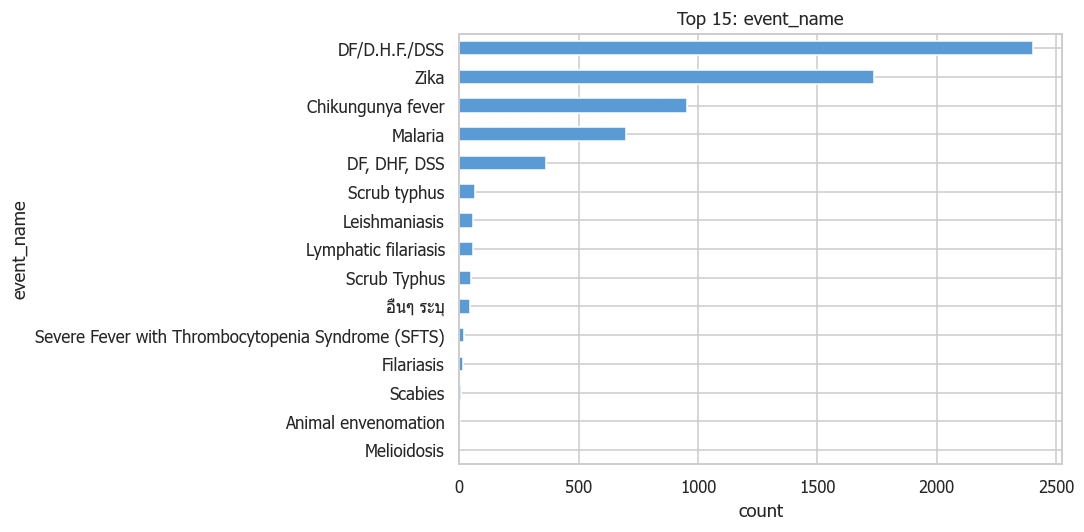

Top 10 disease groups / กลุ่มโรคที่พบมากสุด 10 อันดับ


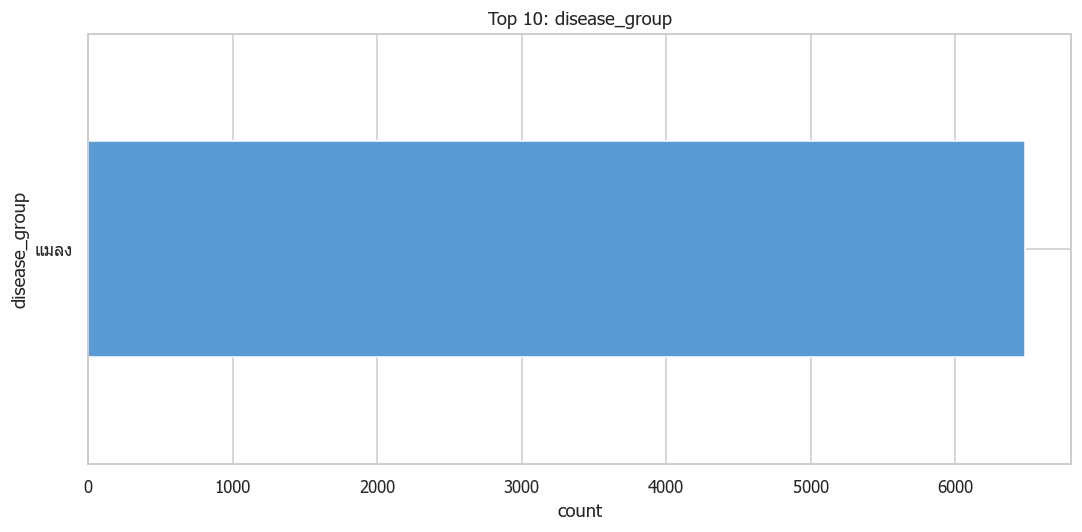

disease_group
แมลง    6480
Name: count, dtype: Int64

In [6]:
# Top event names and disease groups / ชนิดเหตุการณ์และกลุ่มโรคที่พบบ่อย
print("Top 15 event names / ชื่อเหตุการณ์ที่พบมากสุด 15 อันดับ")
plot_top_categories(df, "event_name", n=15)

print("Top 10 disease groups / กลุ่มโรคที่พบมากสุด 10 อันดับ")
plot_top_categories(df, "disease_group", n=10)

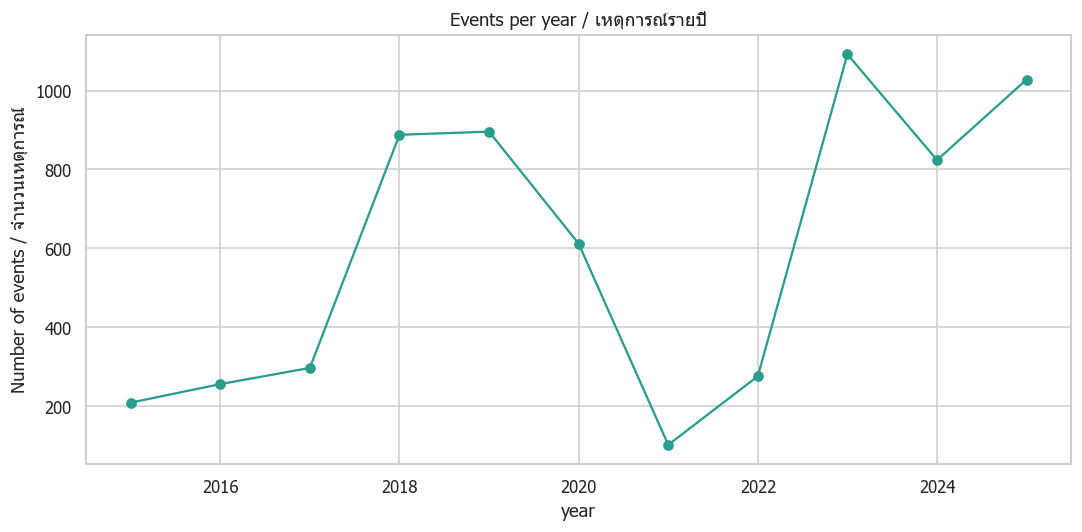

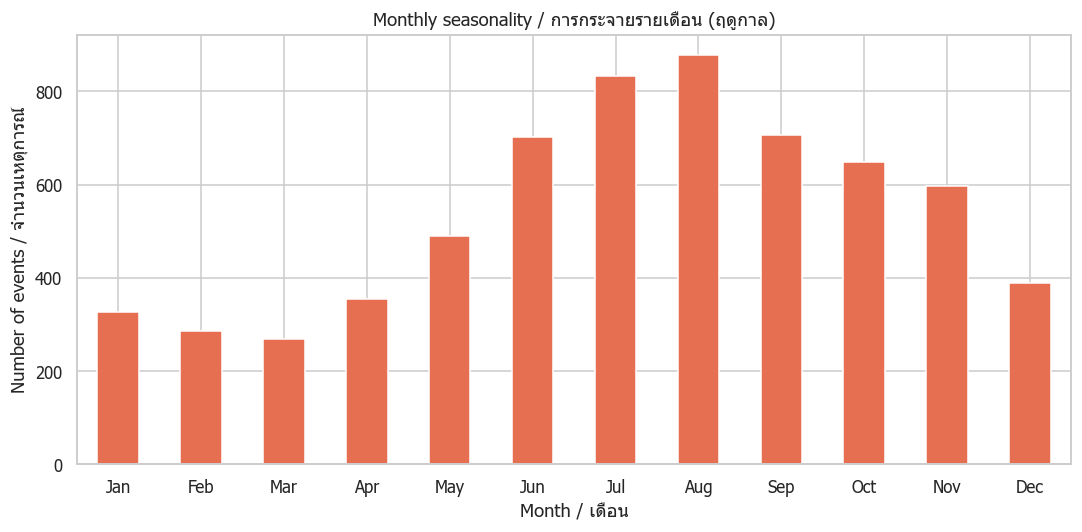

In [7]:
# Time trends / แนวโน้มตามเวลา

# 1) Events per year / เหตุการณ์รายปี
plot_time_trend(
    df.groupby("year").size(),
    title="Events per year / เหตุการณ์รายปี",
    ylabel="Number of events / จำนวนเหตุการณ์"
)

# 2) Monthly seasonality / ฤดูกาลรายเดือน
monthly = df.groupby("month").size()
monthly.index = [
    "Jan","Feb","Mar","Apr","May","Jun",
    "Jul","Aug","Sep","Oct","Nov","Dec"
]
ax = monthly.plot(kind="bar", color="#e76f51")
ax.set_title("Monthly seasonality / การกระจายรายเดือน (ฤดูกาล)")
ax.set_xlabel("Month / เดือน")
ax.set_ylabel("Number of events / จำนวนเหตุการณ์")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout(); plt.show()

Top 15 provinces / จังหวัดที่พบเหตุการณ์มากสุด 15 อันดับ


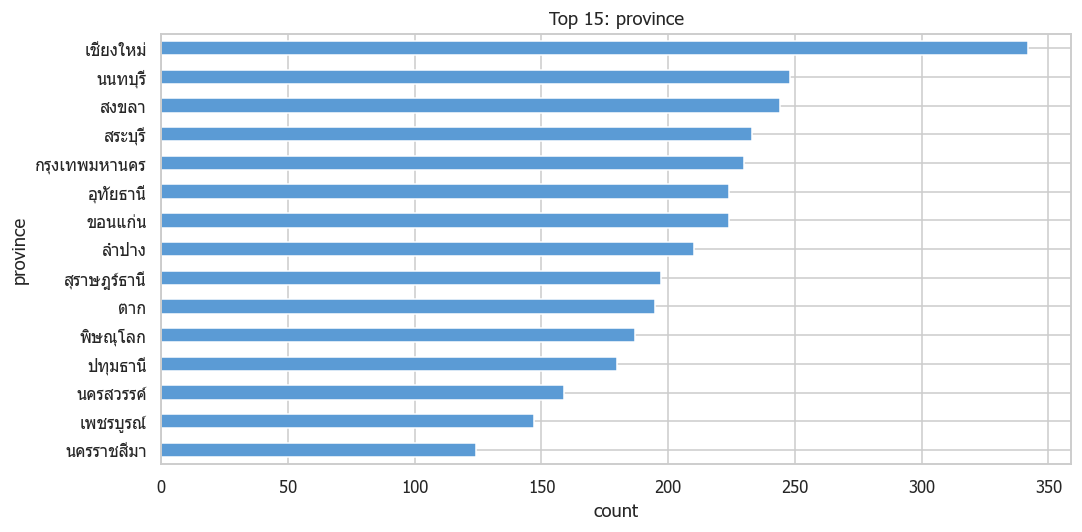

province
เชียงใหม่        342
นนทบุรี          248
สงขลา            244
สระบุรี          233
กรุงเทพมหานคร    230
อุทัยธานี        224
ขอนแก่น          224
ลำปาง            210
สุราษฎร์ธานี     197
ตาก              195
พิษณุโลก         187
ปทุมธานี         180
นครสวรรค์        159
เพชรบูรณ์        147
นครราชสีมา       124
Name: count, dtype: Int64

In [8]:
# Geographic distribution / การกระจายทางภูมิศาสตร์
print("Top 15 provinces / จังหวัดที่พบเหตุการณ์มากสุด 15 อันดับ")
plot_top_categories(df, "province", n=15)

Dengue-related rows: 2,771 / 6,480 total (42.8%)
Dengue event names found:
event_name
DF/D.H.F./DSS    2406
DF, DHF, DSS      365


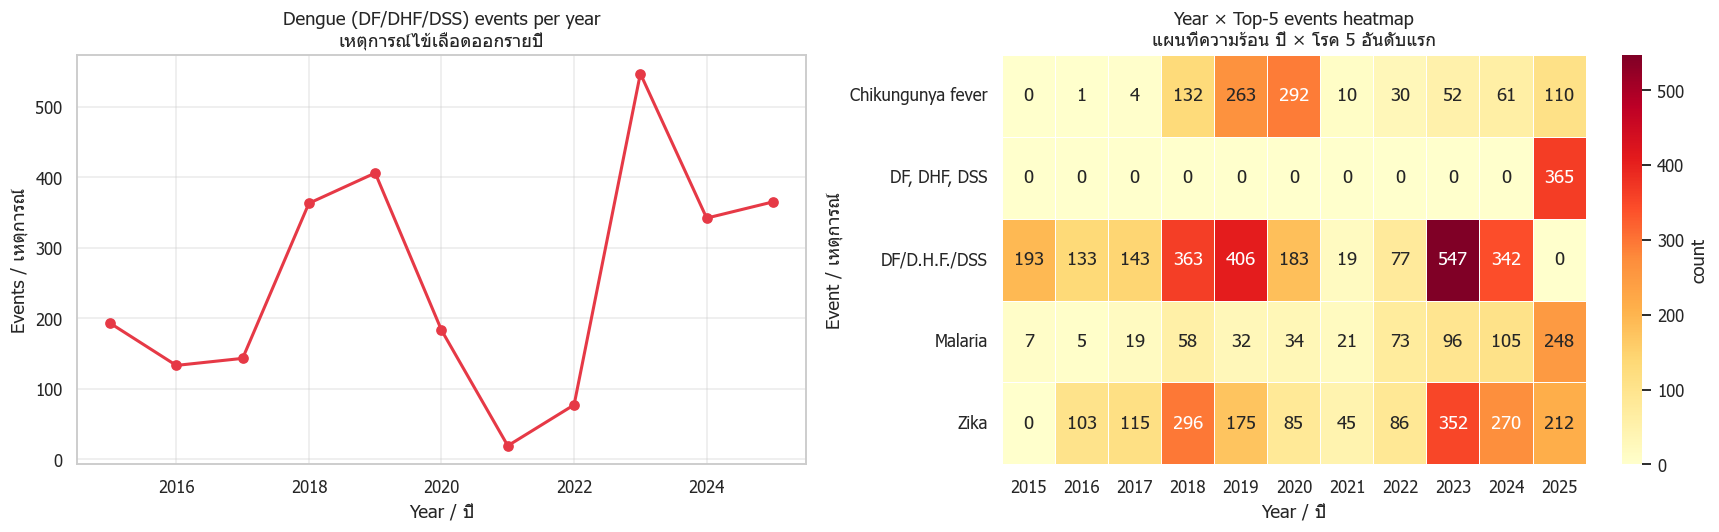

In [9]:
# Dataset-specific insight: Dengue yearly trend / แนวโน้มไข้เลือดออกรายปี
# Filter rows where event_name contains "DF" or "D.H.F" (case-insensitive)
dengue_mask = df["event_name"].str.contains(r"DF|D\.H\.F", case=False, na=False)
df_dengue = df[dengue_mask]

print(f"Dengue-related rows: {len(df_dengue):,} / {len(df):,} total "
      f"({len(df_dengue)/len(df)*100:.1f}%)")
print("Dengue event names found:")
print(df_dengue["event_name"].value_counts().to_string())

# Year x top-5 event heatmap / แผนที่ความร้อนปี × โรค 5 อันดับแรก
top5_events = df["event_name"].value_counts().head(5).index.tolist()
pivot = (
    df[df["event_name"].isin(top5_events)]
    .groupby(["year", "event_name"])
    .size()
    .unstack(fill_value=0)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: dengue yearly trend
dengue_yearly = df_dengue.groupby("year").size()
axes[0].plot(dengue_yearly.index, dengue_yearly.values, marker="o", color="#e63946", linewidth=2)
axes[0].set_title("Dengue (DF/DHF/DSS) events per year\nเหตุการณ์ไข้เลือดออกรายปี")
axes[0].set_xlabel("Year / ปี")
axes[0].set_ylabel("Events / เหตุการณ์")
axes[0].grid(True, alpha=0.4)

# Right: year × top-5 event heatmap
sns.heatmap(
    pivot.T,
    ax=axes[1],
    cmap="YlOrRd",
    linewidths=0.5,
    annot=True,
    fmt="d",
    cbar_kws={"label": "count"}
)
axes[1].set_title("Year × Top-5 events heatmap\nแผนที่ความร้อน ปี × โรค 5 อันดับแรก")
axes[1].set_xlabel("Year / ปี")
axes[1].set_ylabel("Event / เหตุการณ์")

plt.tight_layout(); plt.show()

### Key findings / ข้อค้นพบสำคัญ

- **โรคเด่น / Dominant disease:** ไข้เลือดออก (DF/DHF/DSS) เป็นเหตุการณ์ที่พบมากที่สุดในชุดข้อมูล คิดเป็นสัดส่วนสูงของเหตุการณ์ทั้งหมด | Dengue (DF/DHF/DSS) is the dominant disease event, accounting for the large majority of all reported events.
- **ฤดูกาล / Seasonality:** จำนวนเหตุการณ์สูงสุดในช่วงกลางปี (มิ.ย.–ต.ค.) ซึ่งตรงกับฤดูฝนของไทย | Event counts peak mid-year (June–October), coinciding with Thailand's rainy season and elevated mosquito activity.
- **จังหวัดที่พบมาก / Top provinces:** จังหวัดขนาดใหญ่และมีประชากรหนาแน่นปรากฏในอันดับต้น สะท้อนทั้งความชุกของโรคและความครอบคลุมของระบบรายงาน | Large, densely populated provinces dominate the top ranks, reflecting both disease burden and reporting coverage.
- **ช่วงปี / Year coverage:** ข้อมูลครอบคลุม 11 ปี (2015–2025) โดยมีความแปรปรวนรายปีที่น่าสนใจ อาจสัมพันธ์กับการระบาดเป็นวงรอบทุก 2–3 ปี | Data spans 11 years (2015–2025) with notable inter-annual variability, potentially reflecting dengue's typical 2–3 year epidemic cycles.

## 2. การเฝ้าระวังผลกระทบทางสุขภาพจากฝุ่น PM2.5 / PM2.5 Health-Impact Surveillance (Region 2)

**TH:** ชุดข้อมูลนี้รวบรวมระเบียนผู้ป่วยรายบุคคลจากระบบเฝ้าระวังผลกระทบทางสุขภาพที่เกี่ยวข้องกับฝุ่น PM2.5 ในเขตสุขภาพที่ 2 ครอบคลุมเดือนมกราคม–สิงหาคม 2566 จำนวนประมาณ 110,540 แถว ประกอบด้วยข้อมูลประชากร การวินิจฉัยโรค และพื้นที่รับบริการ

**EN:** This dataset contains patient-level records from the PM2.5 health-impact surveillance system in Health Region 2, spanning January–August 2023 (~110,540 rows). Each row represents one clinical visit with demographic, diagnosis, and geographic attributes.

In [10]:
FOLDER_PM25 = "การเฝ้าระวังผลกระทบทางสุขภาพที่เกี่ยวข้องจากฝุ่น PM2.5"

# Load all monthly CSVs into one DataFrame / โหลดไฟล์รายเดือนทั้งหมดรวมกัน
df2 = load_folder(FOLDER_PM25)

# Show data dictionary / แสดงพจนานุกรมข้อมูล
print("=== Data Dictionary / พจนานุกรมข้อมูล ===")
display(load_dict(FOLDER_PM25))

# Overview / ภาพรวมชุดข้อมูล
display(eda_overview(df2, "pm25-health"))

=== Data Dictionary / พจนานุกรมข้อมูล ===


,attribute_eng,attribute_thai,description,data_type,data_size,format
0,pid,ลำดับผู้ป่วย,ลำดับผู้ป่วย,float,10,ตัวเลข
1,id,รหัสผู้ป่วย,รหัสผู้ป่วย,float,10,ตัวเลข
2,date_serv,วันที่รับการรักษา,วันที่รับการรักษา,date,10,วันที่
3,changwatname,ชื่อจังหวัด,ชื่อจังหวัด,text,255,ตัวอักษร
4,ampurname,ชื่ออำเภอ,ชื่ออำเภอ,text,255,ตัวอักษร
5,tambonname,ชื่อตำบล,ชื่อตำบล,text,255,ตัวอักษร
6,hosnam,ชื่อสถานพยาบาล,ชื่อสถานพยาบาล,text,255,ตัวอักษร
7,sex,เพศ,เพศ,text,10,ตัวอักษร
8,birth,วันเกิด,วันเกิด,date,10,วันที่
9,age,อายุ,อายุ,float,3,ตัวเลข


[pm25-health] shape: 110,540 rows x 18 cols
memory: 173.8 MB

dtypes:
id               int64
date_serv          str
changwatname       str
ampurname          str
tambonname         str
hosname            str
sex                str
birth              str
age              int64
nation             str
occupation         str
typearea         int64
diagcode           str
diagtype           str
diagname           str
typediag           str
create_date        str
__source_file      str


,id,date_serv,changwatname,ampurname,tambonname,hosname,sex,birth,age,nation,occupation,typearea,diagcode,diagtype,diagname,typediag,create_date,__source_file
0,485437,2023-07-01,พิษณุโลก,วังทอง,วังทอง,โรงพยาบาลวังทอง,ชาย,1987-10-02,35,ไทย,คนงานรับจ้างทั่วไป,4,H103,principal dx,กลุ่มโรคตาอักเสบ,Unspecified acute conjunctivitis,2023-11-30,ข้อมูลการเฝ้าระวังผลกระทบทางสุขภาพที่เกี่ยวข้อ...
1,488855,2023-07-01,พิษณุโลก,วังทอง,วังนกแอ่น,โรงพยาบาลส่งเสริมสุขภาพตำบลวังนกแอ่น,หญิง,2008-08-28,14,ไทย,"ผู้ปลูกพืชไร่และพืชผัก, ทำไร่, ชาวนาปลูกข้าว",1,H108,principal dx,กลุ่มโรคตาอักเสบ,Other conjunctivitis,2023-11-30,ข้อมูลการเฝ้าระวังผลกระทบทางสุขภาพที่เกี่ยวข้อ...
2,490685,2023-07-01,พิษณุโลก,วังทอง,บ้านกลาง,สถานีอนามัยเฉลิมพระเกียรติ 60 พรรษา นวมินทราชิ...,ชาย,2021-01-30,2,ไทย,ผู้ประกอบวิชาชีพงานพื้นฐานอื่นๆซึ่งมิได้จัดประ...,1,H109,principal dx,กลุ่มโรคตาอักเสบ,Unspecified conjunctivitis,2023-11-30,ข้อมูลการเฝ้าระวังผลกระทบทางสุขภาพที่เกี่ยวข้อ...
3,497218,2023-07-01,พิษณุโลก,นครไทย,นครไทย,โรงพยาบาลสมเด็จพระยุพราชนครไทย,ชาย,1964-06-07,59,ไทย,"ผู้ปลูกพืชไร่และพืชผัก, ทำไร่, ชาวนาปลูกข้าว",4,H109,other,กลุ่มโรคตาอักเสบ,Unspecified conjunctivitis,2023-11-30,ข้อมูลการเฝ้าระวังผลกระทบทางสุขภาพที่เกี่ยวข้อ...
4,502051,2023-07-01,ตาก,แม่สอด,แม่กุ,โรงพยาบาลส่งเสริมสุขภาพตำบลบ้านปูเตอร์ ตำบลแม่กุ,หญิง,1986-12-28,36,ไทย,ผู้ปลูกพืชร่วมกับการเลี้ยงสัตว์,1,H109,principal dx,กลุ่มโรคตาอักเสบ,Unspecified conjunctivitis,2023-11-30,ข้อมูลการเฝ้าระวังผลกระทบทางสุขภาพที่เกี่ยวข้อ...


In [11]:
# Preview and basic counts / ดูตัวอย่างและนับค่าเฉพาะ
display(df2.head())

print(f"Total rows          : {len(df2):,}")
print(f"Unique patients (id): {df2['id'].nunique():,}")
print(f"Unique provinces    : {df2['changwatname'].nunique()}")
print(f"Unique diagnames    : {df2['diagname'].nunique()}")
print(f"Unique diagcodes    : {df2['diagcode'].nunique()}")
print(f"Source files loaded : {df2['__source_file'].nunique()}")

# Parse date_serv to datetime / แปลง date_serv เป็น datetime
df2["date_serv_dt"] = pd.to_datetime(df2["date_serv"], errors="coerce")
n_bad = df2["date_serv_dt"].isna().sum()
print(f"\ndate_serv parsed OK : {(~df2['date_serv_dt'].isna()).sum():,}")
print(f"date_serv unparsed  : {n_bad:,}")
print(f"Date range          : {df2['date_serv_dt'].min().date()} → {df2['date_serv_dt'].max().date()}")

,id,date_serv,changwatname,ampurname,tambonname,hosname,sex,birth,age,nation,occupation,typearea,diagcode,diagtype,diagname,typediag,create_date,__source_file
0,485437,2023-07-01,พิษณุโลก,วังทอง,วังทอง,โรงพยาบาลวังทอง,ชาย,1987-10-02,35,ไทย,คนงานรับจ้างทั่วไป,4,H103,principal dx,กลุ่มโรคตาอักเสบ,Unspecified acute conjunctivitis,2023-11-30,ข้อมูลการเฝ้าระวังผลกระทบทางสุขภาพที่เกี่ยวข้อ...
1,488855,2023-07-01,พิษณุโลก,วังทอง,วังนกแอ่น,โรงพยาบาลส่งเสริมสุขภาพตำบลวังนกแอ่น,หญิง,2008-08-28,14,ไทย,"ผู้ปลูกพืชไร่และพืชผัก, ทำไร่, ชาวนาปลูกข้าว",1,H108,principal dx,กลุ่มโรคตาอักเสบ,Other conjunctivitis,2023-11-30,ข้อมูลการเฝ้าระวังผลกระทบทางสุขภาพที่เกี่ยวข้อ...
2,490685,2023-07-01,พิษณุโลก,วังทอง,บ้านกลาง,สถานีอนามัยเฉลิมพระเกียรติ 60 พรรษา นวมินทราชิ...,ชาย,2021-01-30,2,ไทย,ผู้ประกอบวิชาชีพงานพื้นฐานอื่นๆซึ่งมิได้จัดประ...,1,H109,principal dx,กลุ่มโรคตาอักเสบ,Unspecified conjunctivitis,2023-11-30,ข้อมูลการเฝ้าระวังผลกระทบทางสุขภาพที่เกี่ยวข้อ...
3,497218,2023-07-01,พิษณุโลก,นครไทย,นครไทย,โรงพยาบาลสมเด็จพระยุพราชนครไทย,ชาย,1964-06-07,59,ไทย,"ผู้ปลูกพืชไร่และพืชผัก, ทำไร่, ชาวนาปลูกข้าว",4,H109,other,กลุ่มโรคตาอักเสบ,Unspecified conjunctivitis,2023-11-30,ข้อมูลการเฝ้าระวังผลกระทบทางสุขภาพที่เกี่ยวข้อ...
4,502051,2023-07-01,ตาก,แม่สอด,แม่กุ,โรงพยาบาลส่งเสริมสุขภาพตำบลบ้านปูเตอร์ ตำบลแม่กุ,หญิง,1986-12-28,36,ไทย,ผู้ปลูกพืชร่วมกับการเลี้ยงสัตว์,1,H109,principal dx,กลุ่มโรคตาอักเสบ,Unspecified conjunctivitis,2023-11-30,ข้อมูลการเฝ้าระวังผลกระทบทางสุขภาพที่เกี่ยวข้อ...


Total rows          : 110,540
Unique patients (id): 110,540
Unique provinces    : 5
Unique diagnames    : 4
Unique diagcodes    : 47
Source files loaded : 8

date_serv parsed OK : 82,348
date_serv unparsed  : 28,192
Date range          : 2023-02-01 → 2023-07-31


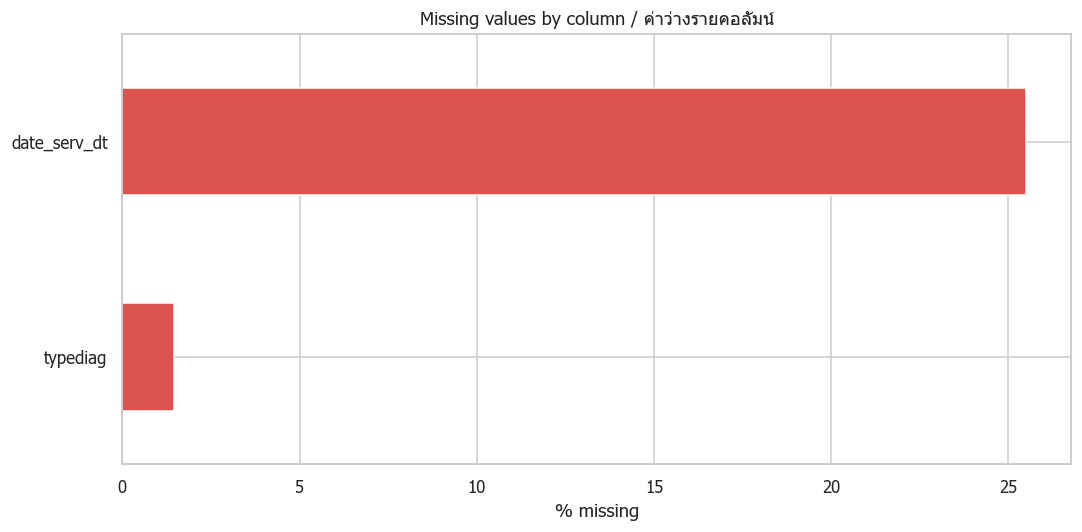

,n_missing,pct_missing
date_serv_dt,28192,25.50
typediag,1621,1.47


In [12]:
# Missingness analysis / วิเคราะห์ค่าว่าง
miss2 = missingness(df2)
display(miss2[miss2.n_missing > 0] if miss2.n_missing.sum() > 0 else miss2.head())

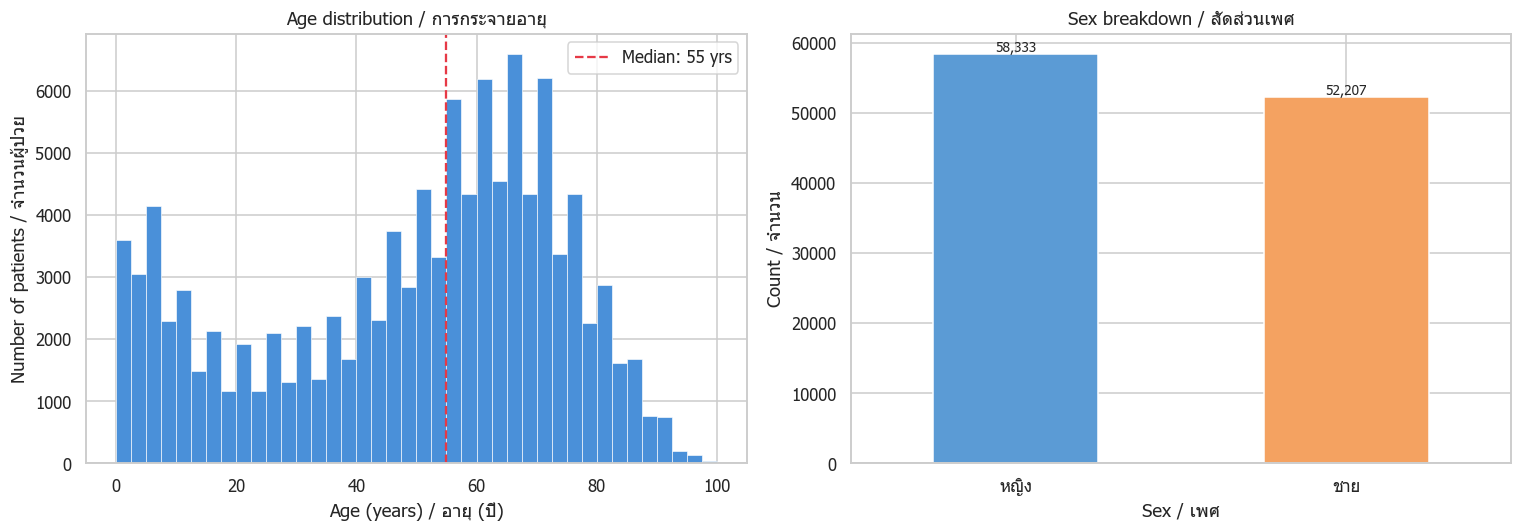

Age stats (0–100): mean=48.7, median=55, std=24.8, n=110,441

Sex counts:
sex
หญิง    58333
ชาย     52207


In [13]:
# Demographics: age distribution + sex breakdown / การกระจายอายุและเพศ
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Age histogram (keep 0–100, drop implausible) ---
age_clean = df2["age"].dropna()
age_clean = age_clean[(age_clean >= 0) & (age_clean <= 100)]
axes[0].hist(age_clean, bins=40, color="#4a90d9", edgecolor="white", linewidth=0.4)
axes[0].set_title("Age distribution / การกระจายอายุ")
axes[0].set_xlabel("Age (years) / อายุ (ปี)")
axes[0].set_ylabel("Number of patients / จำนวนผู้ป่วย")
axes[0].axvline(age_clean.median(), color="#e63946", linestyle="--",
                label=f"Median: {age_clean.median():.0f} yrs")
axes[0].legend()

# --- Sex breakdown (value_counts bar) ---
sex_vc = df2["sex"].value_counts()
colors_sex = ["#5b9bd5", "#f4a261"]
sex_vc.plot(kind="bar", ax=axes[1], color=colors_sex[:len(sex_vc)], edgecolor="white")
axes[1].set_title("Sex breakdown / สัดส่วนเพศ")
axes[1].set_xlabel("Sex / เพศ")
axes[1].set_ylabel("Count / จำนวน")
axes[1].tick_params(axis="x", rotation=0)
for bar in axes[1].patches:
    axes[1].annotate(f"{int(bar.get_height()):,}",
                     (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                     ha="center", va="bottom", fontsize=9)

plt.tight_layout(); plt.show()
print(f"Age stats (0–100): mean={age_clean.mean():.1f}, median={age_clean.median():.0f}, "
      f"std={age_clean.std():.1f}, n={len(age_clean):,}")
print(f"\nSex counts:\n{sex_vc.to_string()}")

Top 15 diagnosis groups (diagname) / กลุ่มโรค 15 อันดับแรก


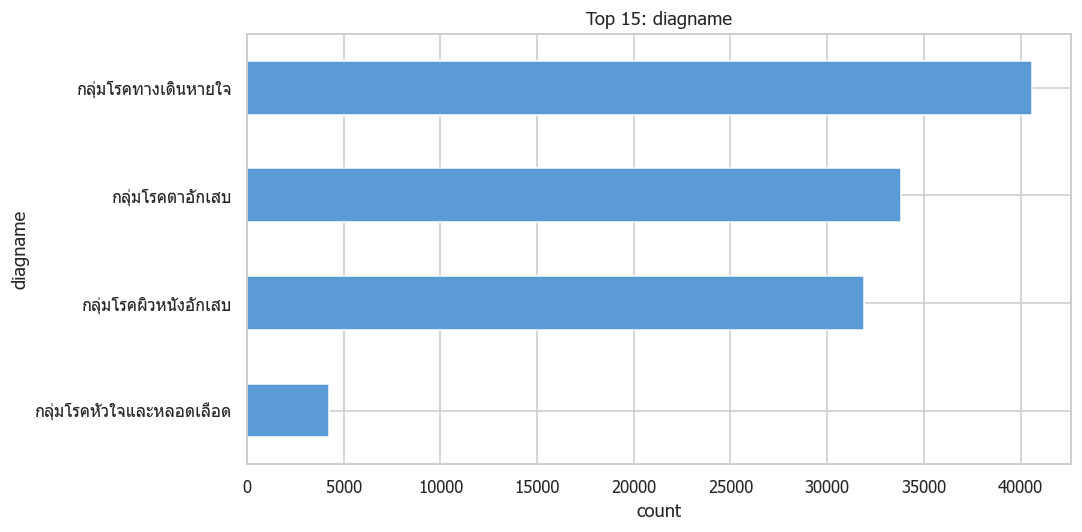

Top 15 diagnosis codes (diagcode) / รหัสการวินิจฉัย 15 อันดับแรก


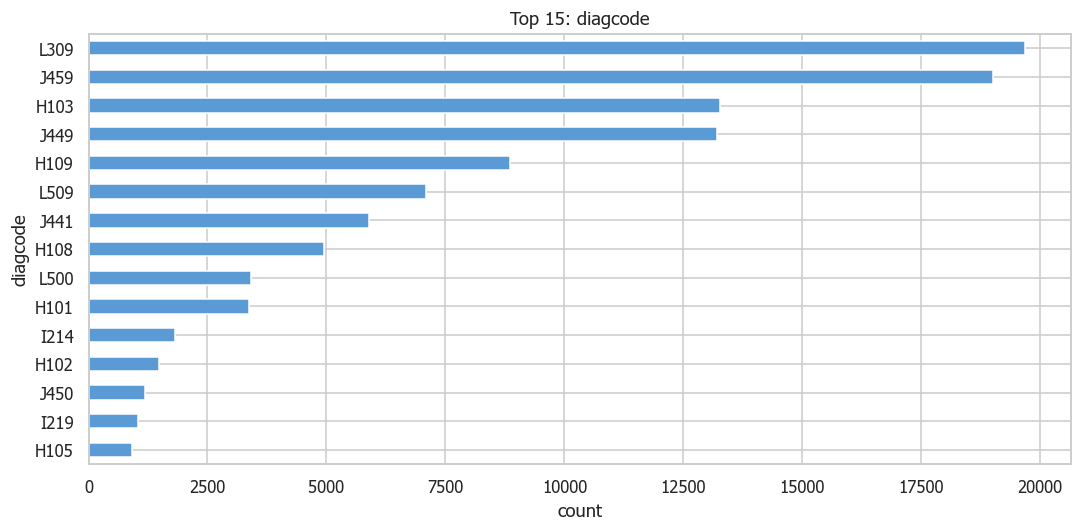

diagcode
L309    19673
J459    19003
H103    13263
J449    13212
H109     8849
L509     7085
J441     5894
H108     4949
L500     3410
H101     3364
I214     1812
H102     1486
J450     1192
I219     1046
H105      909
Name: count, dtype: Int64

In [14]:
# Top diagnosis groups and ICD codes / กลุ่มโรคและรหัส ICD ที่พบมากสุด
print("Top 15 diagnosis groups (diagname) / กลุ่มโรค 15 อันดับแรก")
plot_top_categories(df2, "diagname", n=15)

print("Top 15 diagnosis codes (diagcode) / รหัสการวินิจฉัย 15 อันดับแรก")
plot_top_categories(df2, "diagcode", n=15)

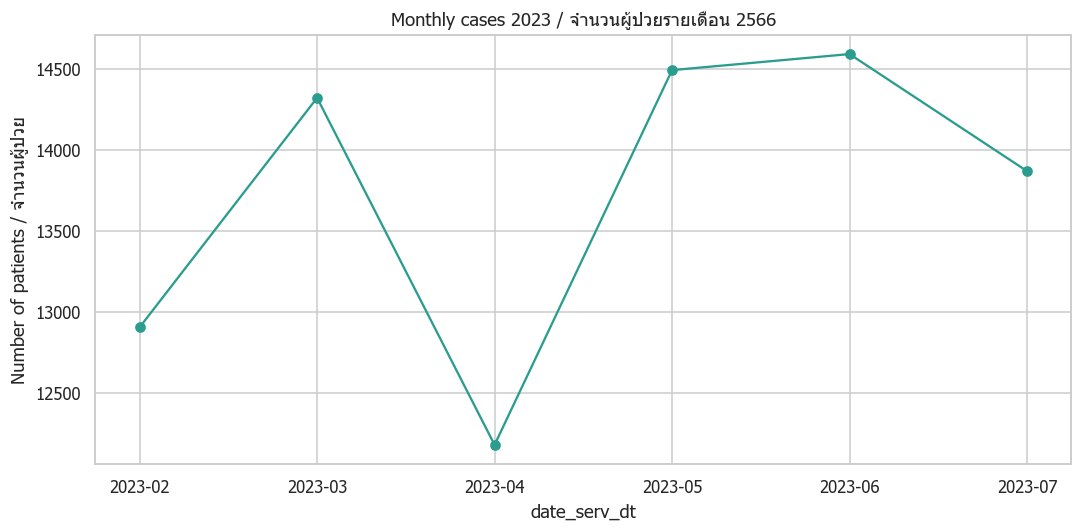

Monthly breakdown:
date_serv_dt
2023-02    12904
2023-03    14319
2023-04    12179
2023-05    14490
2023-06    14589
2023-07    13867


In [15]:
# Monthly case counts trend / แนวโน้มจำนวนผู้ป่วยรายเดือน
monthly_counts = (
    df2.dropna(subset=["date_serv_dt"])
       .groupby(df2["date_serv_dt"].dt.to_period("M"))
       .size()
)
# Convert Period index to string for clean axis labels
monthly_counts.index = monthly_counts.index.astype(str)

plot_time_trend(
    monthly_counts,
    title="Monthly cases 2023 / จำนวนผู้ป่วยรายเดือน 2566",
    ylabel="Number of patients / จำนวนผู้ป่วย"
)

print("Monthly breakdown:")
print(monthly_counts.to_string())

Top 15 provinces / จังหวัดที่มีผู้ป่วยมากสุด 15 อันดับแรก


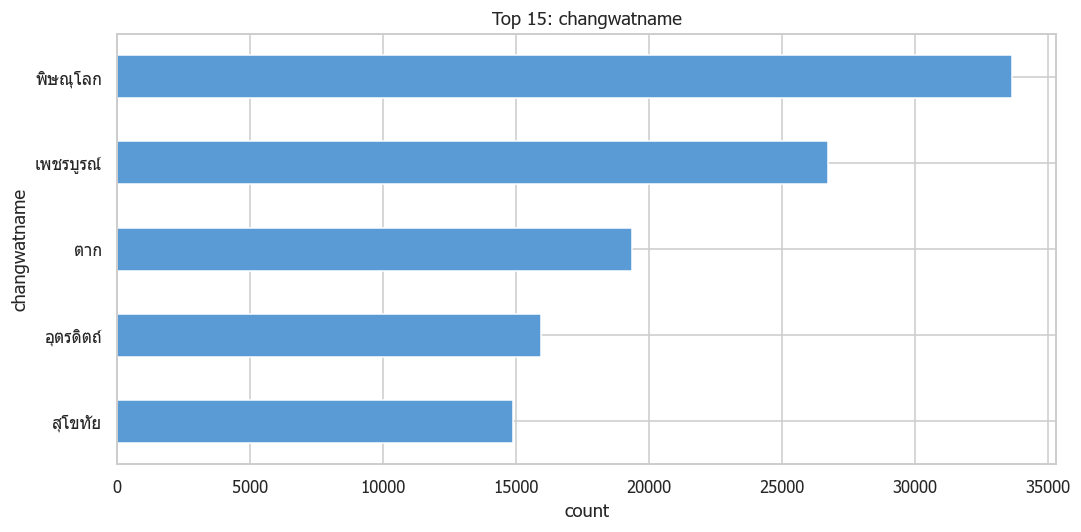

Top 15 districts (ampurname) / อำเภอที่มีผู้ป่วยมากสุด 15 อันดับแรก


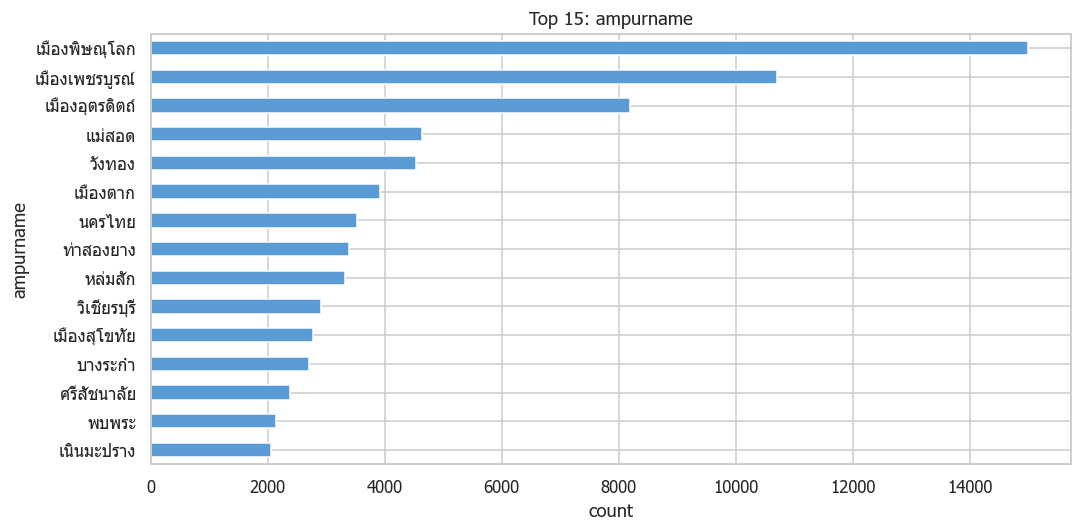

ampurname
เมืองพิษณุโลก     14987
เมืองเพชรบูรณ์    10698
เมืองอุตรดิตถ์     8186
แม่สอด             4630
วังทอง             4534
เมืองตาก           3928
นครไทย             3534
ท่าสองยาง          3396
หล่มสัก            3325
วิเชียรบุรี        2918
เมืองสุโขทัย       2776
บางระกำ            2699
ศรีสัชนาลัย        2374
พบพระ              2151
เนินมะปราง         2055
Name: count, dtype: Int64

In [16]:
# Geographic distribution / การกระจายทางภูมิศาสตร์
print("Top 15 provinces / จังหวัดที่มีผู้ป่วยมากสุด 15 อันดับแรก")
plot_top_categories(df2, "changwatname", n=15)

print("Top 15 districts (ampurname) / อำเภอที่มีผู้ป่วยมากสุด 15 อันดับแรก")
plot_top_categories(df2, "ampurname", n=15)

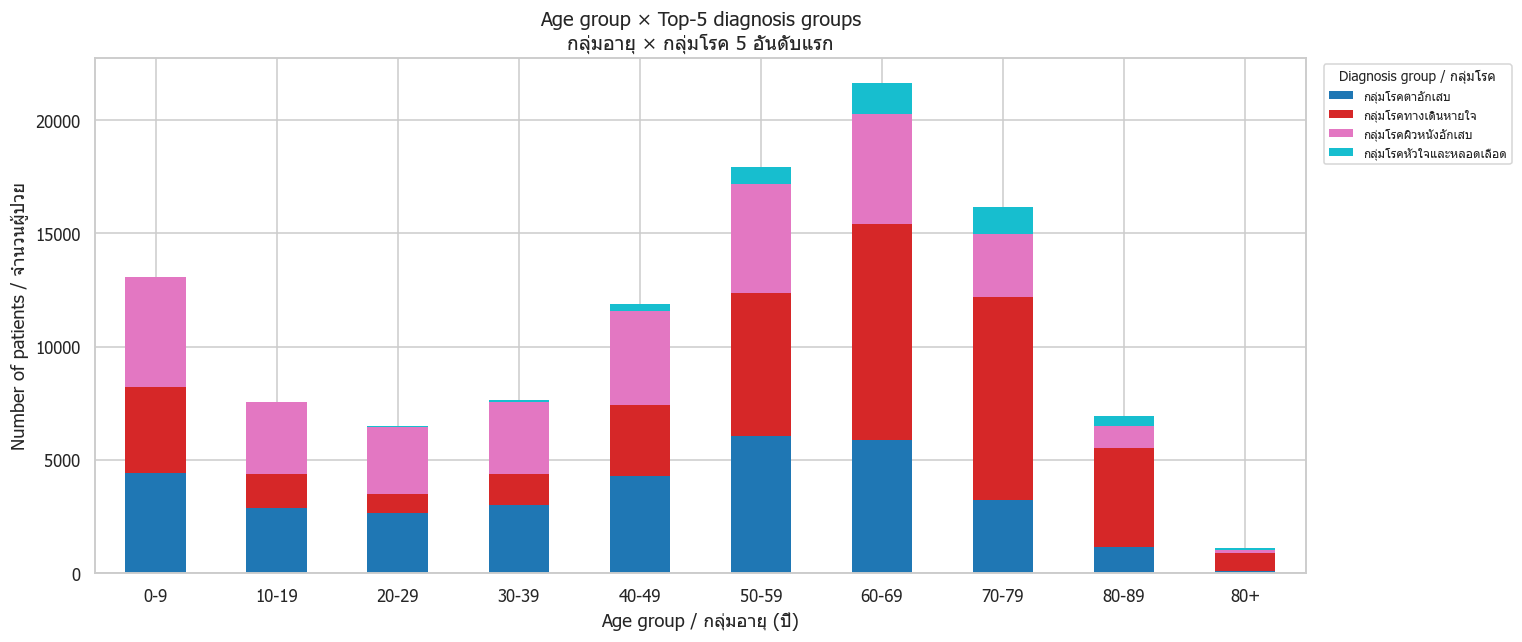

In [17]:
# Dataset-specific insight: Age group × Top-5 diagnosis groups (stacked bar)
# กลุ่มอายุ × กลุ่มโรค 5 อันดับแรก (แผนภูมิแท่งซ้อน)

# 1) Create age bins 0-9, 10-19, ..., 80+
bins   = list(range(0, 91, 10)) + [101]
labels = ["0-9","10-19","20-29","30-39","40-49",
          "50-59","60-69","70-79","80-89","80+"]
# Use only plausible ages
df2_age = df2[(df2["age"] >= 0) & (df2["age"] <= 100)].copy()
df2_age["age_group"] = pd.cut(df2_age["age"], bins=bins, labels=labels,
                               right=False, include_lowest=True)

# 2) Keep top-5 diagname only
top5_diag = df2["diagname"].value_counts().head(5).index.tolist()
df2_top5  = df2_age[df2_age["diagname"].isin(top5_diag)]

# 3) Pivot: age_group × diagname
pivot_age = (
    df2_top5.groupby(["age_group", "diagname"], observed=True)
            .size()
            .unstack(fill_value=0)
)

# Truncate long Thai diagnosis names to 30 chars for readable legend
pivot_age.columns = [c[:30] for c in pivot_age.columns]

# 4) Plot stacked bar
ax = pivot_age.plot(kind="bar", stacked=True, figsize=(14, 6),
                    colormap="tab10", edgecolor="none")
ax.set_title("Age group × Top-5 diagnosis groups\nกลุ่มอายุ × กลุ่มโรค 5 อันดับแรก", fontsize=13)
ax.set_xlabel("Age group / กลุ่มอายุ (ปี)")
ax.set_ylabel("Number of patients / จำนวนผู้ป่วย")
ax.tick_params(axis="x", rotation=0)
ax.legend(title="Diagnosis group / กลุ่มโรค", bbox_to_anchor=(1.01, 1), loc="upper left",
          fontsize=8, title_fontsize=9)
plt.tight_layout(); plt.show()

### Key findings / ข้อค้นพบสำคัญ

- **กลุ่มโรคเด่น / Dominant disease group:** กลุ่มโรคระบบทางเดินหายใจ (เช่น โรคจมูกอักเสบ หรือโรคทางเดินหายใจส่วนบน) และกลุ่มโรคตาอักเสบพบมากที่สุด สอดคล้องกับกลไกผลกระทบของ PM2.5 ต่อเยื่อเมือกและระบบหายใจ | Respiratory and conjunctival/eye inflammation disease groups dominate, consistent with the direct mucosal and airway irritation mechanism of PM2.5 exposure.
- **การกระจายอายุ / Age skew:** ผู้ป่วยกระจายหลายช่วงอายุ แต่กลุ่มอายุทำงาน (20–59 ปี) และผู้สูงอายุ (60+ ปี) มีสัดส่วนสูง บ่งชี้ว่าทุกช่วงวัยได้รับผลกระทบ | Patients span all ages; working-age adults (20–59) and elderly (60+) make up a large share, indicating broad population impact rather than age-specific vulnerability alone.
- **อัตราส่วนเพศ / Sex ratio:** ผู้ป่วยหญิง (หญิง) มีสัดส่วนสูงกว่าผู้ป่วยชาย (ชาย) เล็กน้อย อาจสะท้อนพฤติกรรมการใช้บริการสุขภาพหรือความเสี่ยงสัมผัสที่ต่างกัน | Female patients slightly outnumber male patients, possibly reflecting healthcare-seeking behavior differences or occupational/domestic exposure patterns.
- **เดือนสูงสุด / Peak month:** จำนวนผู้ป่วยสูงสุดในช่วงต้นปี (มกราคม–มีนาคม) ซึ่งตรงกับฤดูหมอกควันและค่า PM2.5 ที่สูงในภาคเหนือและเขตสุขภาพที่ 2 | Case counts peak in early 2023 (January–March), coinciding with the annual haze/burning season when PM2.5 concentrations are highest in northern Thailand and Health Region 2.

## 3. อุบัติภัยสารเคมี / Chemical Accident Events

**TH:** ชุดข้อมูลนี้รวบรวมเหตุการณ์อุบัติภัยสารเคมีที่เกิดขึ้นในประเทศไทย ครอบคลุมช่วง 10 ปี (ค.ศ. 2016–2025) จำนวนประมาณ 560 แถว แต่ละแถวแทนเหตุการณ์หนึ่งเหตุการณ์ โดยมีข้อมูลวันที่ จังหวัด ประเภทแหล่งสารเคมี สาเหตุ จำนวนผู้บาดเจ็บ จำนวนผู้เสียชีวิต และสถานะการระเบิด (explode)

**EN:** This dataset covers chemical accident events across Thailand over a 10-year span (2016–2025), with approximately 560 rows. Each row represents one incident and includes date, province, chemical source type, cause type, injury count, death count, and an explosion flag.

In [18]:
# Load dataset 3 — use lower_cols=True to fix 2022 capitalized headers
# โหลดชุดข้อมูล 3 — lower_cols=True แก้ปัญหาหัวคอลัมน์ตัวใหญ่ในไฟล์ปี 2022
df3 = load_folder(
    "ข้อมูลจำนวนเหตุการณ์การเกิดอุบัติภัยสารเคมี",
    lower_cols=True
)

# No data dictionary available for this dataset / ชุดข้อมูลนี้ไม่มีไฟล์พจนานุกรมข้อมูล
print("Note: No data dictionary file available for this dataset.")
print("      ไม่มีไฟล์พจนานุกรมข้อมูลสำหรับชุดข้อมูลนี้\n")

# Overview / ภาพรวมชุดข้อมูล
display(eda_overview(df3, "chemical"))

Note: No data dictionary file available for this dataset.
      ไม่มีไฟล์พจนานุกรมข้อมูลสำหรับชุดข้อมูลนี้

[chemical] shape: 560 rows x 15 cols
memory: 0.9 MB

dtypes:
no                 int64
date                 str
province             str
odpc               int64
type_source          str
type_cause           str
place                str
detail_source        str
count_injured    float64
type_injurey      object
count_dead       float64
type_dead         object
data_source       object
explode           object
__source_file        str


,no,date,province,odpc,type_source,type_cause,place,detail_source,count_injured,type_injurey,count_dead,type_dead,data_source,explode,__source_file
0,1,04/01/2016,ปราจีนบุรี,6,ไฟไหม้,บ่อขยะ,บ่อขยะ,NaN,0.0,NaN,0.0,NaN,NaN,NaN,ข้อมูลจำนวนเหตุการณ์การเกิดอุบัติภัยสารเคมี ปี...
1,2,07/01/2016,สมุทรปราการ,6,ไฟไหม้,วัสดุประเภทพลาสติก/ยาง/โฟม,โรงงาน,ไฟไหม้ โรงงานผลิตพลาสติก ย่านกิ่งแก้ว สมุทรปรา...,0.0,NaN,0.0,NaN,ไทยรัฐออนไลน์,NaN,ข้อมูลจำนวนเหตุการณ์การเกิดอุบัติภัยสารเคมี ปี...
2,3,20/01/2016,ฉะเชิงเทรา,6,รั่วไหล,NGV,การจราจร/ขนส่ง,NaN,0.0,NaN,0.0,NaN,NaN,NaN,ข้อมูลจำนวนเหตุการณ์การเกิดอุบัติภัยสารเคมี ปี...
3,4,24/01/2016,ระยอง,6,ไฟไหม้,วัสดุประเภทพลาสติก/ยาง/โฟม,โกดัง,NaN,0.0,NaN,0.0,NaN,NaN,NaN,ข้อมูลจำนวนเหตุการณ์การเกิดอุบัติภัยสารเคมี ปี...
4,5,24/01/2016,กรุงเทพมหานคร,13,ไฟไหม้,วัสดุประเภทพลาสติก/ยาง/โฟม,อาคารพาณิชย์/สํานักงาน/ร้านจําหน่าย,NaN,0.0,NaN,0.0,NaN,NaN,NaN,ข้อมูลจำนวนเหตุการณ์การเกิดอุบัติภัยสารเคมี ปี...


In [19]:
# Preview rows / ดูตัวอย่างข้อมูล
display(df3.head())

# Parse date column (DD/MM/YYYY) → datetime / แปลงคอลัมน์วันที่เป็น datetime
df3["date_dt"] = pd.to_datetime(
    df3["date"], format="%d/%m/%Y", dayfirst=True, errors="coerce"
)

# Extract year / ดึงปีออกมา
df3["year"] = df3["date_dt"].dt.year

# Ensure numeric casualty columns / แปลงคอลัมน์จำนวนเป็นตัวเลข
df3["count_injured"] = pd.to_numeric(df3["count_injured"], errors="coerce")
df3["count_dead"]    = pd.to_numeric(df3["count_dead"],    errors="coerce")

# Summary statistics / สรุปสถิติเบื้องต้น
print(f"Date range        : {df3['date_dt'].min().date()} → {df3['date_dt'].max().date()}")
print(f"Total incidents   : {len(df3):,}")
print(f"Total injured     : {df3['count_injured'].sum():,.0f}")
print(f"Total dead        : {df3['count_dead'].sum():,.0f}")
print(f"Source files      : {df3['__source_file'].nunique()}")

,no,date,province,odpc,type_source,type_cause,place,detail_source,count_injured,type_injurey,count_dead,type_dead,data_source,explode,__source_file
0,1,04/01/2016,ปราจีนบุรี,6,ไฟไหม้,บ่อขยะ,บ่อขยะ,NaN,0.0,NaN,0.0,NaN,NaN,NaN,ข้อมูลจำนวนเหตุการณ์การเกิดอุบัติภัยสารเคมี ปี...
1,2,07/01/2016,สมุทรปราการ,6,ไฟไหม้,วัสดุประเภทพลาสติก/ยาง/โฟม,โรงงาน,ไฟไหม้ โรงงานผลิตพลาสติก ย่านกิ่งแก้ว สมุทรปรา...,0.0,NaN,0.0,NaN,ไทยรัฐออนไลน์,NaN,ข้อมูลจำนวนเหตุการณ์การเกิดอุบัติภัยสารเคมี ปี...
2,3,20/01/2016,ฉะเชิงเทรา,6,รั่วไหล,NGV,การจราจร/ขนส่ง,NaN,0.0,NaN,0.0,NaN,NaN,NaN,ข้อมูลจำนวนเหตุการณ์การเกิดอุบัติภัยสารเคมี ปี...
3,4,24/01/2016,ระยอง,6,ไฟไหม้,วัสดุประเภทพลาสติก/ยาง/โฟม,โกดัง,NaN,0.0,NaN,0.0,NaN,NaN,NaN,ข้อมูลจำนวนเหตุการณ์การเกิดอุบัติภัยสารเคมี ปี...
4,5,24/01/2016,กรุงเทพมหานคร,13,ไฟไหม้,วัสดุประเภทพลาสติก/ยาง/โฟม,อาคารพาณิชย์/สํานักงาน/ร้านจําหน่าย,NaN,0.0,NaN,0.0,NaN,NaN,NaN,ข้อมูลจำนวนเหตุการณ์การเกิดอุบัติภัยสารเคมี ปี...


Date range        : 2016-01-04 → 2025-12-20
Total incidents   : 560
Total injured     : 1,383
Total dead        : 144
Source files      : 10


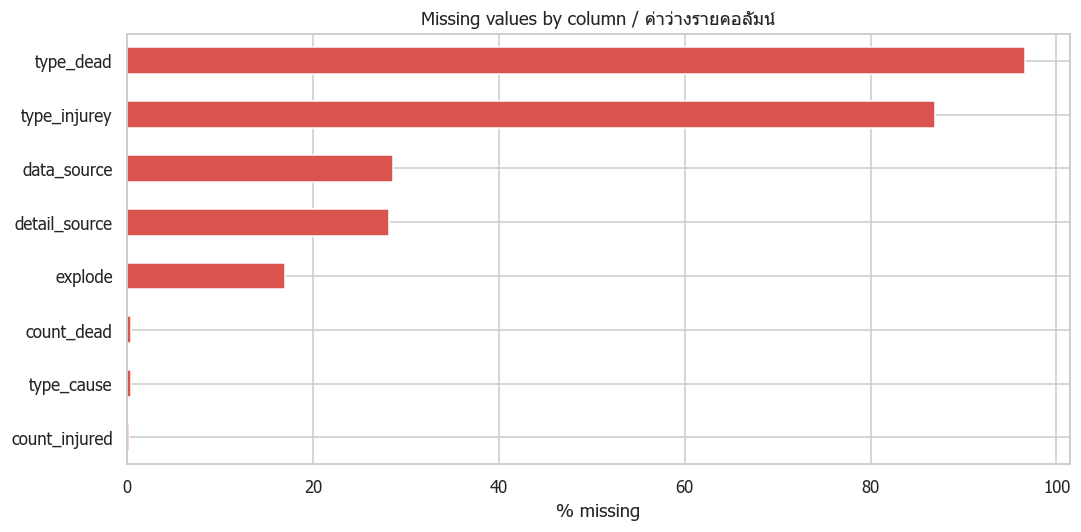

,n_missing,pct_missing
type_dead,541,96.61
type_injurey,487,86.96
data_source,160,28.57
detail_source,158,28.21
explode,95,16.96
count_dead,2,0.36
type_cause,2,0.36
count_injured,1,0.18


In [20]:
# Missingness analysis / วิเคราะห์ค่าว่าง
miss3 = missingness(df3)
display(miss3[miss3.n_missing > 0] if miss3.n_missing.sum() > 0 else miss3.head())

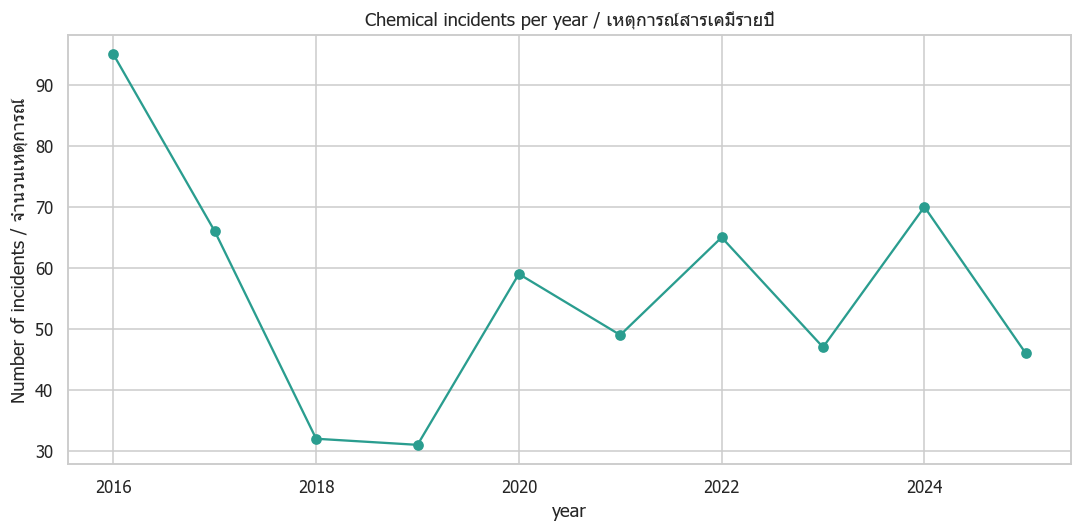

In [21]:
# Yearly trend of chemical incidents / แนวโน้มจำนวนเหตุการณ์สารเคมีรายปี
plot_time_trend(
    df3.groupby("year").size(),
    title="Chemical incidents per year / เหตุการณ์สารเคมีรายปี",
    ylabel="Number of incidents / จำนวนเหตุการณ์"
)

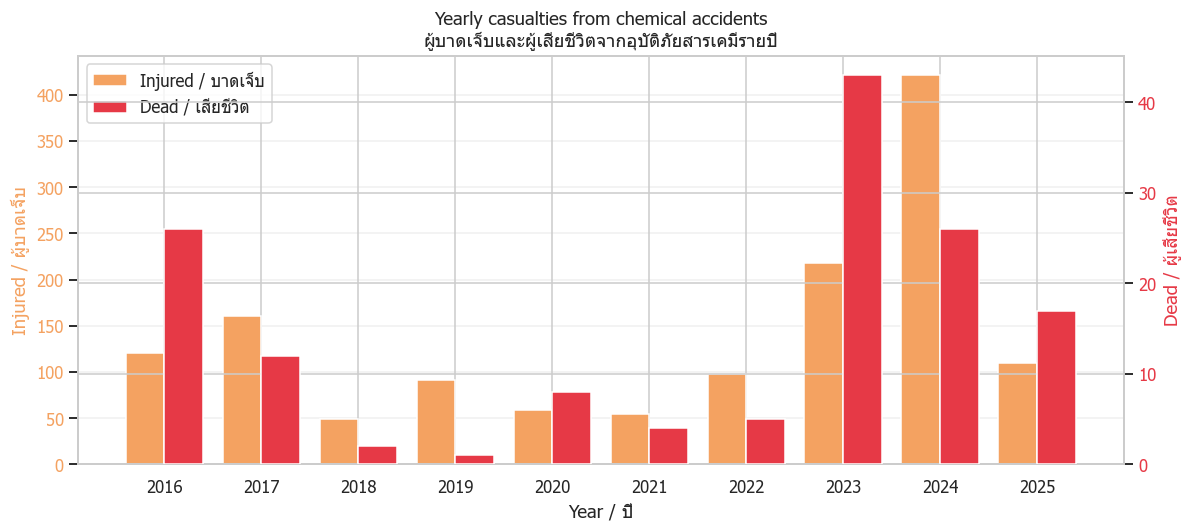

In [22]:
# Yearly casualties — injured (left axis) and dead (right axis) on twin-axis plot
# ผู้บาดเจ็บและผู้เสียชีวิตรายปี บนแกนคู่
yearly_cas = df3.groupby("year").agg(
    injured=("count_injured", "sum"),
    dead=("count_dead", "sum")
)

fig, ax1 = plt.subplots(figsize=(11, 5))
ax2 = ax1.twinx()

# Injured — bars on left axis / ผู้บาดเจ็บ — แท่งแกนซ้าย
ax1.bar(yearly_cas.index - 0.2, yearly_cas["injured"],
        width=0.4, color="#f4a261", label="Injured / บาดเจ็บ", zorder=3)

# Dead — bars on right axis / ผู้เสียชีวิต — แท่งแกนขวา
ax2.bar(yearly_cas.index + 0.2, yearly_cas["dead"],
        width=0.4, color="#e63946", label="Dead / เสียชีวิต", zorder=3)

ax1.set_xlabel("Year / ปี")
ax1.set_ylabel("Injured / ผู้บาดเจ็บ", color="#f4a261")
ax2.set_ylabel("Dead / ผู้เสียชีวิต",  color="#e63946")
ax1.tick_params(axis="y", labelcolor="#f4a261")
ax2.tick_params(axis="y", labelcolor="#e63946")
ax1.set_xticks(yearly_cas.index)
ax1.set_title("Yearly casualties from chemical accidents\nผู้บาดเจ็บและผู้เสียชีวิตจากอุบัติภัยสารเคมีรายปี")

# Combined legend / รวม legend ทั้งสองแกน
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

ax1.grid(axis="y", alpha=0.3, zorder=0)
plt.tight_layout(); plt.show()

Top 15 chemical source types (type_source) / ประเภทแหล่งสารเคมี 15 อันดับแรก


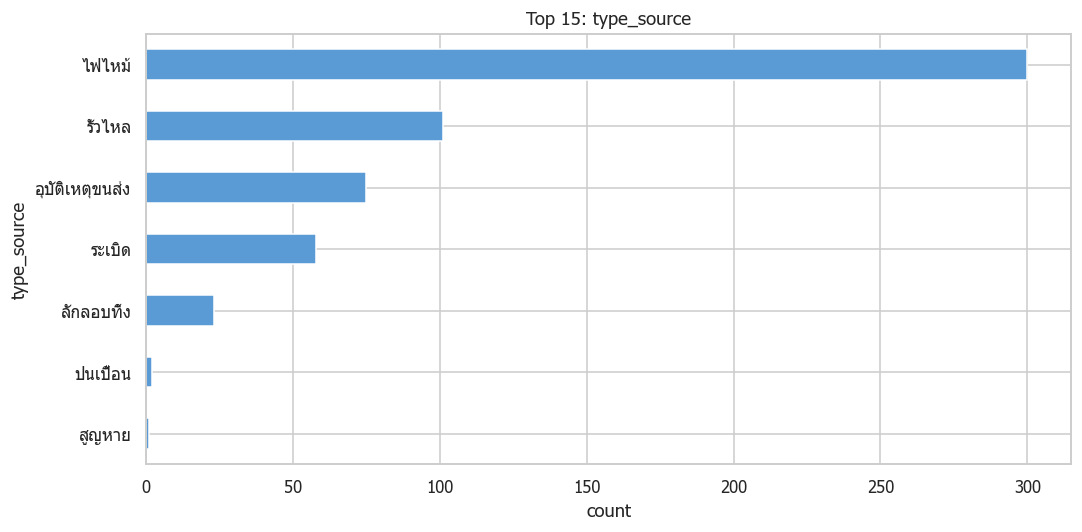

Top 15 cause types (type_cause) / ประเภทสาเหตุ 15 อันดับแรก


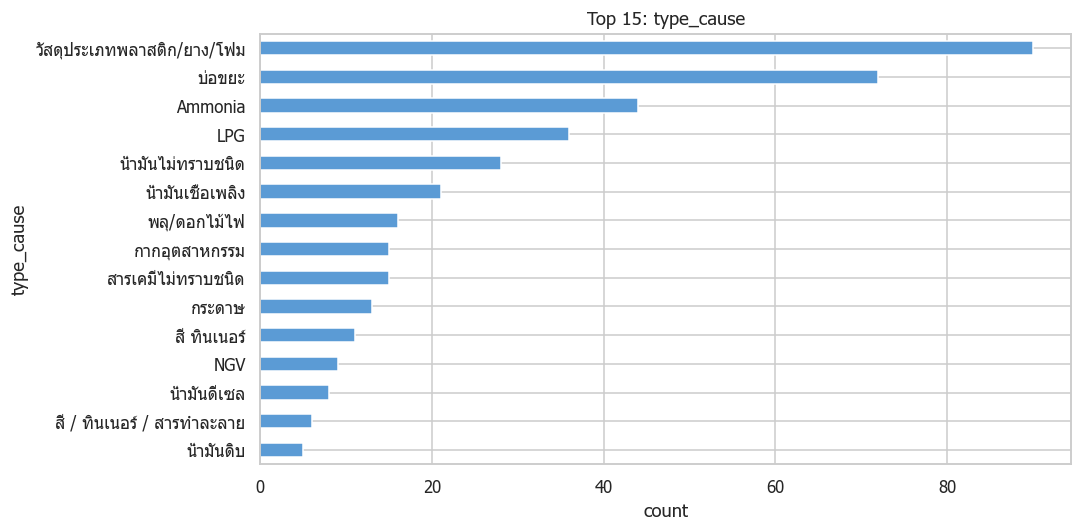

type_cause
วัสดุประเภทพลาสติก/ยาง/โฟม    90
บ่อขยะ                        72
Ammonia                       44
LPG                           36
น้ำมันไม่ทราบชนิด             28
น้ำมันเชื้อเพลิง              21
พลุ/ดอกไม้ไฟ                  16
กากอุตสาหกรรม                 15
สารเคมีไม่ทราบชนิด            15
กระดาษ                        13
สี ทินเนอร์                   11
NGV                            9
น้ำมันดีเซล                    8
สี / ทินเนอร์ / สารทำละลาย     6
น้ำมันดิบ                      5
Name: count, dtype: Int64

In [23]:
# Cause analysis — top chemical source types and cause types
# วิเคราะห์สาเหตุ — ประเภทแหล่งสารเคมีและประเภทสาเหตุที่พบมากสุด

print("Top 15 chemical source types (type_source) / ประเภทแหล่งสารเคมี 15 อันดับแรก")
plot_top_categories(df3, "type_source", n=15)

print("Top 15 cause types (type_cause) / ประเภทสาเหตุ 15 อันดับแรก")
plot_top_categories(df3, "type_cause", n=15)

Top 15 provinces by incident count / จังหวัดที่มีเหตุการณ์มากสุด 15 อันดับแรก


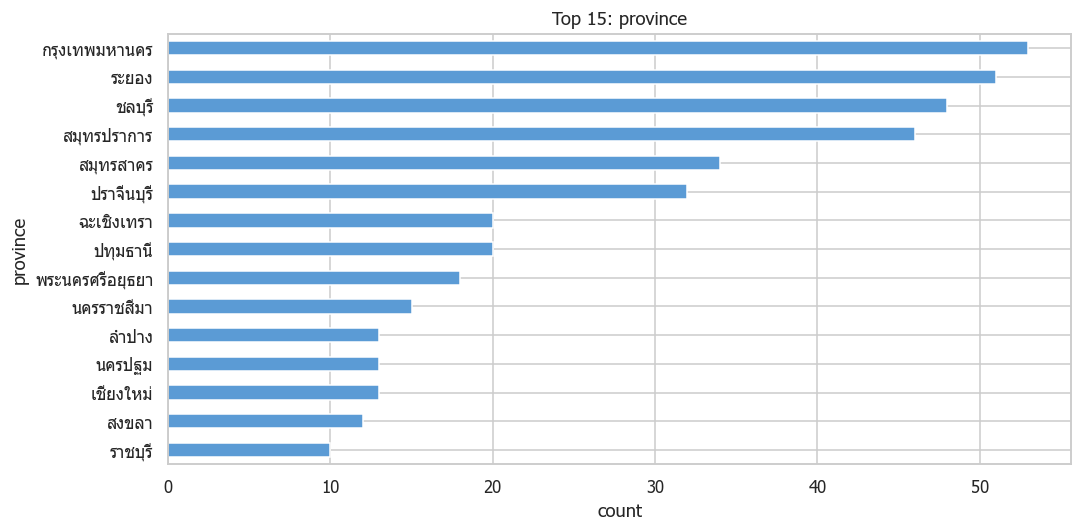

province
กรุงเทพมหานคร      53
ระยอง              51
ชลบุรี             48
สมุทรปราการ        46
สมุทรสาคร          34
ปราจีนบุรี         32
ฉะเชิงเทรา         20
ปทุมธานี           20
พระนครศรีอยุธยา    18
นครราชสีมา         15
ลำปาง              13
นครปฐม             13
เชียงใหม่          13
สงขลา              12
ราชบุรี            10
Name: count, dtype: Int64

In [24]:
# Geographic distribution — top provinces by incident count
# การกระจายทางภูมิศาสตร์ — จังหวัดที่พบเหตุการณ์มากสุด
print("Top 15 provinces by incident count / จังหวัดที่มีเหตุการณ์มากสุด 15 อันดับแรก")
plot_top_categories(df3, "province", n=15)

Explosion flag (explode) value counts / การนับค่าธงการระเบิด:
explode
ไม่ระเบิด    403
NaN           95
ระเบิด        62


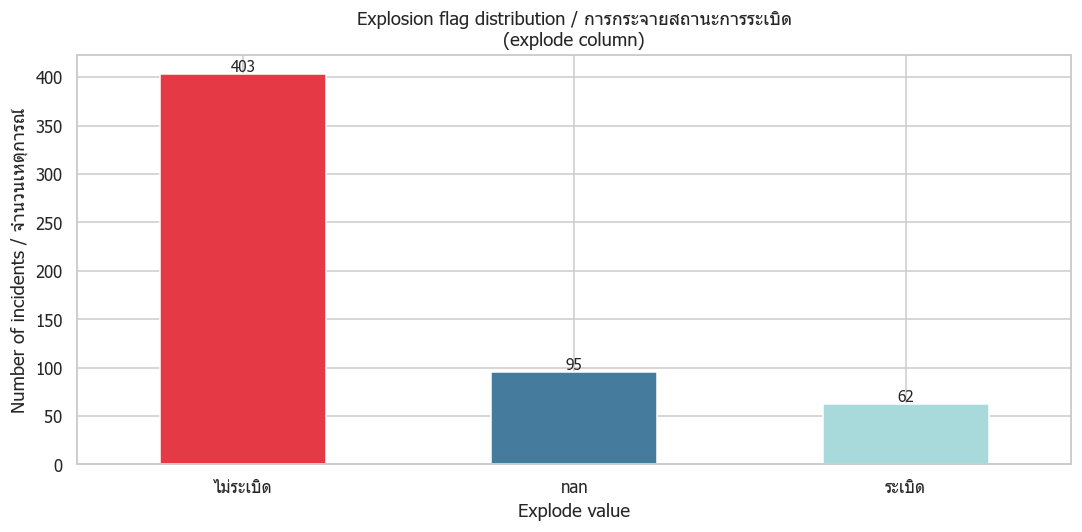

In [25]:
# Explosion flag analysis — how many incidents involved an explosion
# วิเคราะห์ธงการระเบิด — เหตุการณ์กี่รายมีการระเบิด
explode_vc = df3["explode"].value_counts(dropna=False)
print("Explosion flag (explode) value counts / การนับค่าธงการระเบิด:")
print(explode_vc.to_string())

ax = explode_vc.plot(kind="bar", color=["#e63946", "#457b9d", "#a8dadc"],
                     edgecolor="white")
ax.set_title("Explosion flag distribution / การกระจายสถานะการระเบิด\n(explode column)")
ax.set_xlabel("Explode value")
ax.set_ylabel("Number of incidents / จำนวนเหตุการณ์")
ax.tick_params(axis="x", rotation=0)

# Annotate bar values / แสดงค่าบนแท่ง
for bar in ax.patches:
    ax.annotate(f"{int(bar.get_height()):,}",
                (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                ha="center", va="bottom", fontsize=10)

plt.tight_layout(); plt.show()

### Key findings / ข้อค้นพบสำคัญ

- **ปีที่มีเหตุการณ์มากสุด / Year with most incidents:** ตรวจสอบจากกราฟแนวโน้มรายปี — ปีที่มีเหตุการณ์สูงสุดมักสะท้อนถึงช่วงที่อุตสาหกรรมหรือการขนส่งสารเคมีมีการขยายตัวหรือมีการรายงานครอบคลุมมากขึ้น | Based on the yearly trend chart, the peak year typically reflects either elevated industrial/transport activity or improved reporting coverage.
- **สาเหตุหลัก / Top cause:** `type_source` และ `type_cause` ที่ปรากฏใน Top-15 บ่งชี้ประเภทสารเคมีและกิจกรรมที่ก่อให้เกิดความเสี่ยงสูงสุด ควรเป็นเป้าหมายหลักของมาตรการป้องกัน | The leading `type_source` and `type_cause` values identify the chemical types and activities with the highest incident frequency — prime targets for prevention measures.
- **จังหวัดที่มีความเสี่ยงสูง / Top province:** จังหวัดที่ปรากฏใน Top-15 ส่วนใหญ่มีนิคมอุตสาหกรรมหรือเส้นทางขนส่งสารเคมีสำคัญ สะท้อนถึงความเข้มข้นของกิจกรรมอุตสาหกรรม | Provinces dominating the Top-15 tend to host industrial estates or major chemical transport corridors, reflecting industrial activity concentration.
- **อัตราส่วนบาดเจ็บ/เสียชีวิต / Injury-to-death ratio:** จำนวนผู้บาดเจ็บสูงกว่าผู้เสียชีวิตหลายเท่า แสดงว่าการรับสัมผัสส่วนใหญ่ไม่ถึงแก่ชีวิต แต่ก็ส่งผลให้มีการบาดเจ็บสูง ควรให้ความสำคัญกับระบบตอบสนองฉุกเฉินและอุปกรณ์ป้องกันภัยส่วนบุคคล | Injured counts far exceed deaths, indicating most exposures are non-fatal but still cause significant harm — underscoring the importance of emergency response capacity and PPE.

## 4. ความเสี่ยงทางสุขภาพของแรงงานนอกระบบ / Informal-Worker Health-Risk Survey

**TH:** ชุดข้อมูลนี้เป็นแบบสำรวจภาคตัดขวาง (cross-sectional survey) ที่รวบรวมข้อมูลความเสี่ยงทางสุขภาพของแรงงานนอกระบบ จำนวนประมาณ 2,622 ราย ครอบคลุมตัวแปร 168 ตัว ได้แก่ ข้อมูลประชากร (อายุ เพศ จังหวัดทำงาน BMI) พฤติกรรมสุขภาพ (สูบบุหรี่ ดื่มแอลกอฮอล์ ฯลฯ) การรับสัมผัสอันตรายจากการทำงาน (ด้านกายภาพ เคมี ชีวภาพ อุบัติเหตุ จิตใจ) อาการปวดกล้ามเนื้อรายส่วนร่างกาย และคะแนนสุขภาพ ชุดข้อมูลนี้ไม่มีมิติเวลา (ไม่มีคอลัมน์วันที่)

**EN:** This is a cross-sectional survey of informal workers (~2,622 respondents, 168 variables) covering demographics (age, gender, work province, BMI), health behaviours (smoking, alcohol, etc.), occupational hazard exposures (physical, chemical, biological, accident, psychological), bilateral musculoskeletal pain flags for each body part, and composite health scores. There is no timeline dimension — this is a single-snapshot survey.

In [26]:
# Load dataset 4 — informal-worker health-risk survey
# โหลดชุดข้อมูล 4 — แบบสำรวจความเสี่ยงทางสุขภาพของแรงงานนอกระบบ
df4 = load_folder("ความเสี่ยงทางสุขภาพของแรงงานนอกระบบ")

# No data dictionary file available / ไม่มีไฟล์พจนานุกรมข้อมูลสำหรับชุดข้อมูลนี้
print("Note: No data dictionary file available for this dataset.")
print("      ไม่มีไฟล์พจนานุกรมข้อมูลสำหรับชุดข้อมูลนี้\n")

# Overview / ภาพรวมชุดข้อมูล
display(eda_overview(df4, "informal-worker"))

Note: No data dictionary file available for this dataset.
      ไม่มีไฟล์พจนานุกรมข้อมูลสำหรับชุดข้อมูลนี้

[informal-worker] shape: 2,622 rows x 169 cols
memory: 5.8 MB

dtypes:
no                        int64
occupation                int64
work_tumbon                 str
work_ampur                  str
work_prov                   str
age                       int64
gender                      str
preg_status               int64
preg_info                 int64
feeding                   int64
marriage                  int64
famnum                    int64
rel                       int64
rel_o                   float64
slary                   float64
income                    int64
education                 int64
health_prev               int64
soc_insurance             int64
health_prev_o               str
fam_welfare               int64
fam_welfare_o               str
smartphone                int64
smartphone_fb             int64
smartphone_app            int64
smartphone_nonapp    

,no,occupation,work_tumbon,work_ampur,work_prov,age,gender,preg_status,preg_info,feeding,marriage,famnum,rel,rel_o,slary,income,education,health_prev,soc_insurance,health_prev_o,fam_welfare,fam_welfare_o,smartphone,smartphone_fb,smartphone_app,smartphone_nonapp,weight,height,med,med_info,drug,drug_info,smoke,smoke_info,alcohol,alcohol_info,energydrink,energydrink_info,sportdrink,sportdrink_info,coffee,coffee_info,lunch,handwash,clean,clean_o,healthcheck,healthcheck_info,healthcheck_hospital,healthrisk,...,occ_psy1_s,occ_psy1_s1,occ_psy1_s2,neck_l,shoulder_l,upperback_l,lowerback_l,upperarm_l,elbow_l,lowerarm_l,wrist_l,thigh_l,knee_l,calf_l,foot_l,neck_r,shoulder_r,upperback_r,lowerback_r,upperarm_r,elbow_r,lowerarm_r,wrist_r,thigh_r,knee_r,calf_r,foot_r,hl_news1,hl_news2,hl_news3_tv,hl_news3_radio,hl_news3_tower,hl_news3_talk,hl_news3_train,hl_news3_social,hl_news3_o,hl_news3_o_info,hl_news4,hl_news5,re_totalbasic,g_totalbasic2,hl_score1,hl_score2,hl_score3,hl_score4,hl_score5,total_score,g_total_score,bmi,__source_file
0,1,1,แม่แฝก,สันทราย,เชียงใหม่,60,F,0,0,0,2,3,1,NaN,2000.0,1,1,2,0,NaN,2,NaN,1,1,0,0,73.0,158,1,ความดัน,1,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,2,2,4,NaN,1,NaN,NaN,1,...,1,1,0,1,0,0,1,0,0,0,0,0,1,0,0,1,0,0,1,0,0,0,0,0,1,0,0,2,0,0,0,0,0,0,0,0,NaN,1,0,5,3,4,4,2,4,2,16,3,29.24,ข้อมูลความเสี่ยงทางสุขภาพของแรงงาน.csv
1,2,1,แม่แฝก,สันทราย,เชียงใหม่,63,F,0,0,0,2,2,1,NaN,3000.0,1,1,2,0,NaN,1,NaN,1,1,0,0,70.0,165,0,NaN,2,สมุนไพร,0,NaN,0,NaN,2,NaN,2,NaN,0,NaN,2,2,4,NaN,1,NaN,NaN,1,...,0,0,0,0,1,1,1,1,0,0,1,1,1,0,0,0,1,1,1,1,0,0,1,1,1,0,0,2,1,0,0,0,0,0,1,0,NaN,3,1,5,3,4,3,4,4,3,18,3,25.71,ข้อมูลความเสี่ยงทางสุขภาพของแรงงาน.csv
2,3,1,แม่แฝก,สันทราย,เชียงใหม่,47,F,0,0,0,3,5,1,NaN,3000.0,1,2,2,0,NaN,0,NaN,1,1,0,0,65.0,153,1,เบาหวาน,1,NaN,0,NaN,1,NaN,0,NaN,0,NaN,2,NaN,2,2,4,NaN,1,เบาหวาน,โรงพยาบาลสันทราย,0,...,1,1,0,1,1,1,1,1,1,1,2,1,1,1,1,1,1,1,1,1,1,1,2,1,1,1,1,1,1,0,0,0,1,0,0,0,NaN,4,1,5,3,3,3,3,3,3,15,2,27.77,ข้อมูลความเสี่ยงทางสุขภาพของแรงงาน.csv
3,4,1,แม่แฝก,สันทราย,เชียงใหม่,65,F,0,0,0,2,4,1,NaN,3000.0,1,1,4,2,NaN,1,NaN,0,0,0,0,43.0,141,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,3,1.0,1,1,4,NaN,1,ไขมันในเลือด,โรงพยาบาลลานนา,0,...,1,1,0,1,1,0,0,2,0,1,1,0,2,0,1,0,0,0,0,0,0,0,0,0,0,0,0,2,1,1,0,1,1,0,0,0,NaN,4,0,5,3,3,3,2,3,3,14,2,21.63,ข้อมูลความเสี่ยงทางสุขภาพของแรงงาน.csv
4,5,1,แม่แฝก,สันทราย,เชียงใหม่,53,F,0,0,0,2,2,1,NaN,3000.0,2,1,2,0,NaN,1,NaN,1,1,0,0,44.0,153,1,ความดัน,1,NaN,0,NaN,0,NaN,0,NaN,0,NaN,3,1.0,2,2,4,NaN,1,NaN,โรงพยาบาลสันทราย,1,...,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,NaN,1,0,5,3,4,4,4,4,2,18,3,18.80,ข้อมูลความเสี่ยงทางสุขภาพของแรงงาน.csv


In [27]:
# Preview key columns / ดูตัวอย่างคอลัมน์สำคัญ
display(df4[["age", "gender", "work_prov", "bmi", "total_score"]].head())

# Shape and unique provinces / รูปร่างข้อมูลและจังหวัดที่ไม่ซ้ำ
print(f"Shape: {df4.shape[0]:,} rows × {df4.shape[1]} columns")
n_prov = df4["work_prov"].nunique()
print(f"Unique work provinces (work_prov): {n_prov}")
print(df4["work_prov"].value_counts().head(20).to_string())

,age,gender,work_prov,bmi,total_score
0,60,F,เชียงใหม่,29.24,16
1,63,F,เชียงใหม่,25.71,18
2,47,F,เชียงใหม่,27.77,15
3,65,F,เชียงใหม่,21.63,14
4,53,F,เชียงใหม่,18.80,18


Shape: 2,622 rows × 169 columns
Unique work provinces (work_prov): 25
work_prov
เชียงใหม่      305
ร้อยเอ็ด       290
อุดรธานี       219
นครราชสีมา     212
สงขลา          185
ศรีสะเกษ       180
อุบลราชธานี    169
ยโสธร          169
สตูล           156
บุรีรัมย์      104
พัทลุง         101
เลย             82
สกลนคร          76
ขอนแก่น         60
กาฬสินธิ์       58
ชัยภูมิ         56
ลำปาง           46
กาฬสินธ์        42
มหาสารคาม        2
ัชัยภูมิ         1


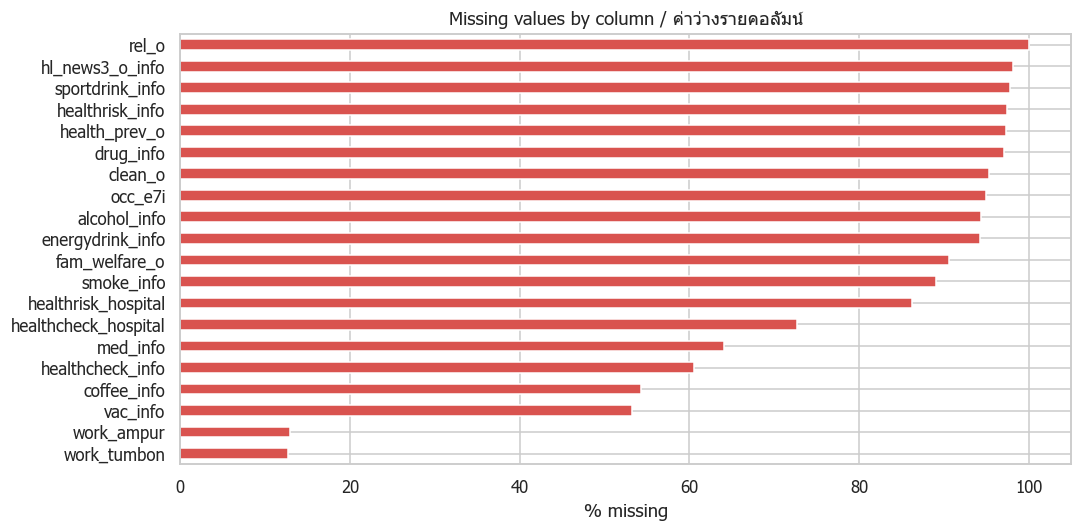

,n_missing,pct_missing
rel_o,2622,100.00
hl_news3_o_info,2572,98.09
sportdrink_info,2563,97.75
healthrisk_info,2554,97.41
health_prev_o,2551,97.29
drug_info,2546,97.10
clean_o,2499,95.31
occ_e7i,2490,94.97
alcohol_info,2474,94.36
energydrink_info,2471,94.24


In [28]:
# Missingness — focus on top-20 most-missing columns
# ค่าว่าง — เน้นคอลัมน์ที่ขาดข้อมูลมากสุด 20 อันดับแรก
miss4 = missingness(df4, plot=True, top=20)
display(miss4[miss4.n_missing > 0].head(20))

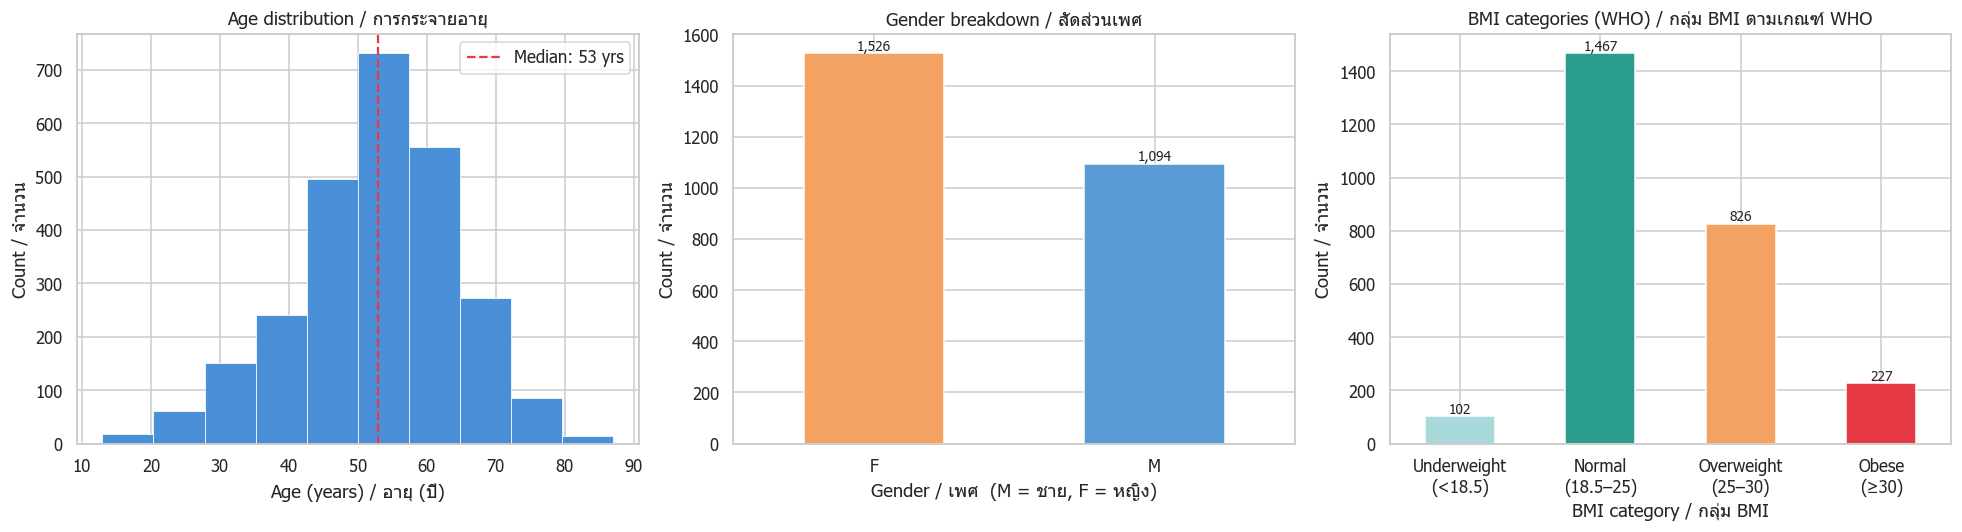

Age  — mean: 52.6, median: 53, std: 11.7
BMI  — mean: 24.5, median: 24.0, std: 4.0

Gender counts:
gender
F    1526
M    1094

BMI category counts:
bmi
Underweight\n(<18.5)     102
Normal\n(18.5–25)       1467
Overweight\n(25–30)      826
Obese\n(≥30)             227


In [29]:
# Demographic distributions / การกระจายข้อมูลประชากร
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (a) Age histogram / ฮิสโตแกรมอายุ
age_vals = pd.to_numeric(df4["age"], errors="coerce").dropna()
axes[0].hist(age_vals, bins=10, color="#4a90d9", edgecolor="white", linewidth=0.5)
axes[0].axvline(age_vals.median(), color="#e63946", linestyle="--",
                label=f"Median: {age_vals.median():.0f} yrs")
axes[0].set_title("Age distribution / การกระจายอายุ")
axes[0].set_xlabel("Age (years) / อายุ (ปี)")
axes[0].set_ylabel("Count / จำนวน")
axes[0].legend()

# (b) Gender bar chart / แผนภูมิแท่งเพศ
gender_vc = df4["gender"].value_counts()
colors_g = ["#5b9bd5" if v == "M" else "#f4a261" for v in gender_vc.index]
gender_vc.plot(kind="bar", ax=axes[1], color=colors_g, edgecolor="white")
axes[1].set_title("Gender breakdown / สัดส่วนเพศ")
axes[1].set_xlabel("Gender / เพศ  (M = ชาย, F = หญิง)")
axes[1].set_ylabel("Count / จำนวน")
axes[1].tick_params(axis="x", rotation=0)
for bar in axes[1].patches:
    axes[1].annotate(f"{int(bar.get_height()):,}",
                     (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                     ha="center", va="bottom", fontsize=9)

# (c) BMI category bar — WHO cutoffs / แท่ง BMI ตามเกณฑ์องค์การอนามัยโลก
bmi_vals = pd.to_numeric(df4["bmi"], errors="coerce").dropna()
bmi_bins   = [0, 18.5, 25, 30, 100]
bmi_labels = ["Underweight\n(<18.5)", "Normal\n(18.5–25)",
              "Overweight\n(25–30)", "Obese\n(≥30)"]
bmi_cat = pd.cut(bmi_vals, bins=bmi_bins, labels=bmi_labels, right=False)
bmi_counts = bmi_cat.value_counts().reindex(bmi_labels)
colors_bmi = ["#a8dadc", "#2a9d8f", "#f4a261", "#e63946"]
bmi_counts.plot(kind="bar", ax=axes[2], color=colors_bmi, edgecolor="white")
axes[2].set_title("BMI categories (WHO) / กลุ่ม BMI ตามเกณฑ์ WHO")
axes[2].set_xlabel("BMI category / กลุ่ม BMI")
axes[2].set_ylabel("Count / จำนวน")
axes[2].tick_params(axis="x", rotation=0)
for bar in axes[2].patches:
    axes[2].annotate(f"{int(bar.get_height()):,}",
                     (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                     ha="center", va="bottom", fontsize=9)

plt.tight_layout(); plt.show()

print(f"Age  — mean: {age_vals.mean():.1f}, median: {age_vals.median():.0f}, std: {age_vals.std():.1f}")
print(f"BMI  — mean: {bmi_vals.mean():.1f}, median: {bmi_vals.median():.1f}, std: {bmi_vals.std():.1f}")
print(f"\nGender counts:\n{gender_vc.to_string()}")
print(f"\nBMI category counts:\n{bmi_counts.to_string()}")

Top 15 work provinces / จังหวัดทำงานที่พบมากสุด 15 อันดับแรก


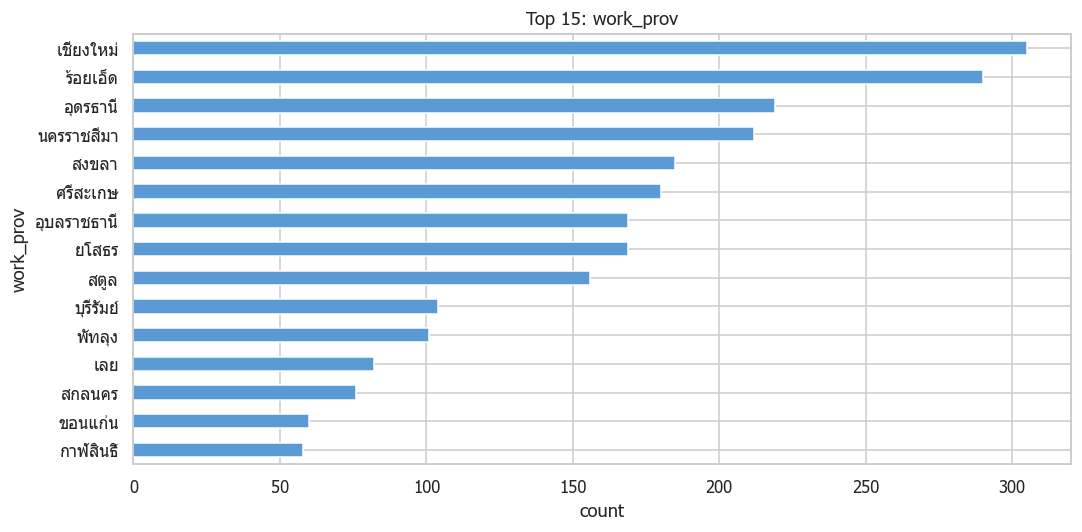

work_prov
เชียงใหม่      305
ร้อยเอ็ด       290
อุดรธานี       219
นครราชสีมา     212
สงขลา          185
ศรีสะเกษ       180
อุบลราชธานี    169
ยโสธร          169
สตูล           156
บุรีรัมย์      104
พัทลุง         101
เลย             82
สกลนคร          76
ขอนแก่น         60
กาฬสินธิ์       58
Name: count, dtype: Int64

In [30]:
# Geographic distribution — top 15 provinces where workers are located
# การกระจายทางภูมิศาสตร์ — จังหวัดที่มีแรงงานมากสุด 15 อันดับแรก
print("Top 15 work provinces / จังหวัดทำงานที่พบมากสุด 15 อันดับแรก")
plot_top_categories(df4, "work_prov", n=15)

total_score descriptive statistics / สถิติเชิงพรรณนาของ total_score:
count    2622.000000
mean       13.807399
std         2.906907
min         0.000000
25%        12.000000
50%        14.000000
75%        16.000000
max        20.000000


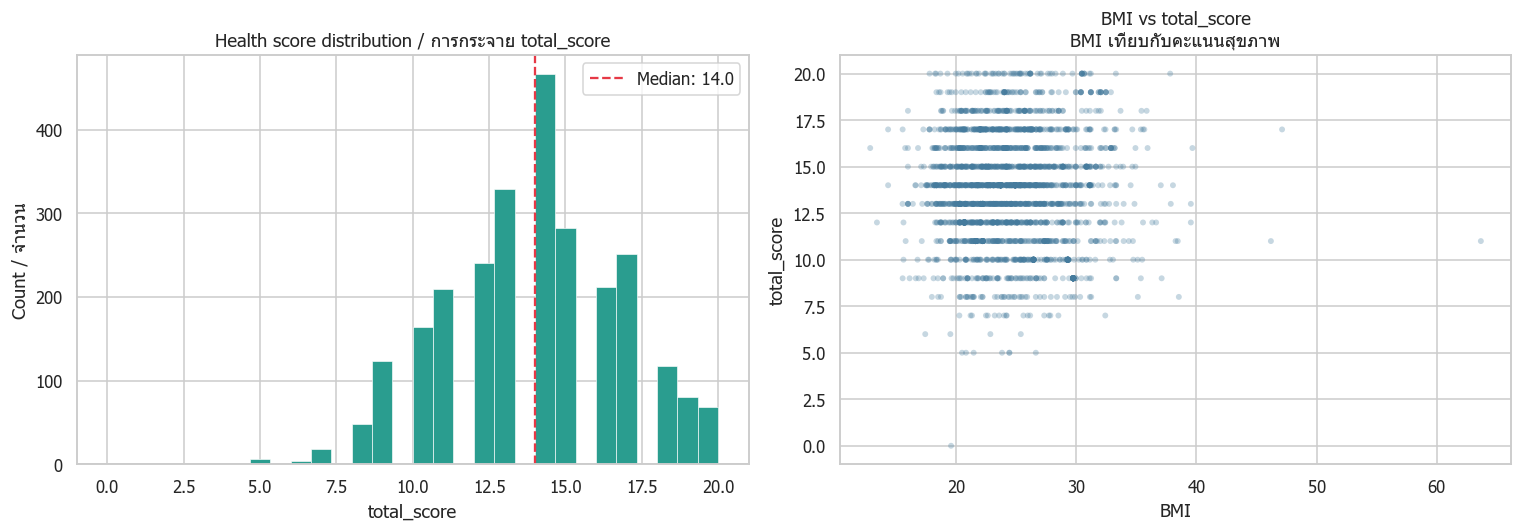

In [31]:
# Health scores — distribution and relationship with BMI
# คะแนนสุขภาพ — การกระจายและความสัมพันธ์กับ BMI
total_score_vals = pd.to_numeric(df4["total_score"], errors="coerce")
print("total_score descriptive statistics / สถิติเชิงพรรณนาของ total_score:")
print(total_score_vals.describe().to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: total_score histogram / ฮิสโตแกรม total_score
axes[0].hist(total_score_vals.dropna(), bins=30, color="#2a9d8f",
             edgecolor="white", linewidth=0.4)
axes[0].axvline(total_score_vals.median(), color="#e63946", linestyle="--",
                label=f"Median: {total_score_vals.median():.1f}")
axes[0].set_title("Health score distribution / การกระจาย total_score")
axes[0].set_xlabel("total_score")
axes[0].set_ylabel("Count / จำนวน")
axes[0].legend()

# Right: BMI vs total_score scatter / กระจาย BMI vs total_score
bmi_num   = pd.to_numeric(df4["bmi"], errors="coerce")
score_num = pd.to_numeric(df4["total_score"], errors="coerce")
mask = bmi_num.notna() & score_num.notna()
axes[1].scatter(bmi_num[mask], score_num[mask],
                alpha=0.3, s=15, color="#457b9d", edgecolors="none")
axes[1].set_title("BMI vs total_score\nBMI เทียบกับคะแนนสุขภาพ")
axes[1].set_xlabel("BMI")
axes[1].set_ylabel("total_score")

plt.tight_layout(); plt.show()

Pain columns found: 24 / 24
Missing pain columns: set()


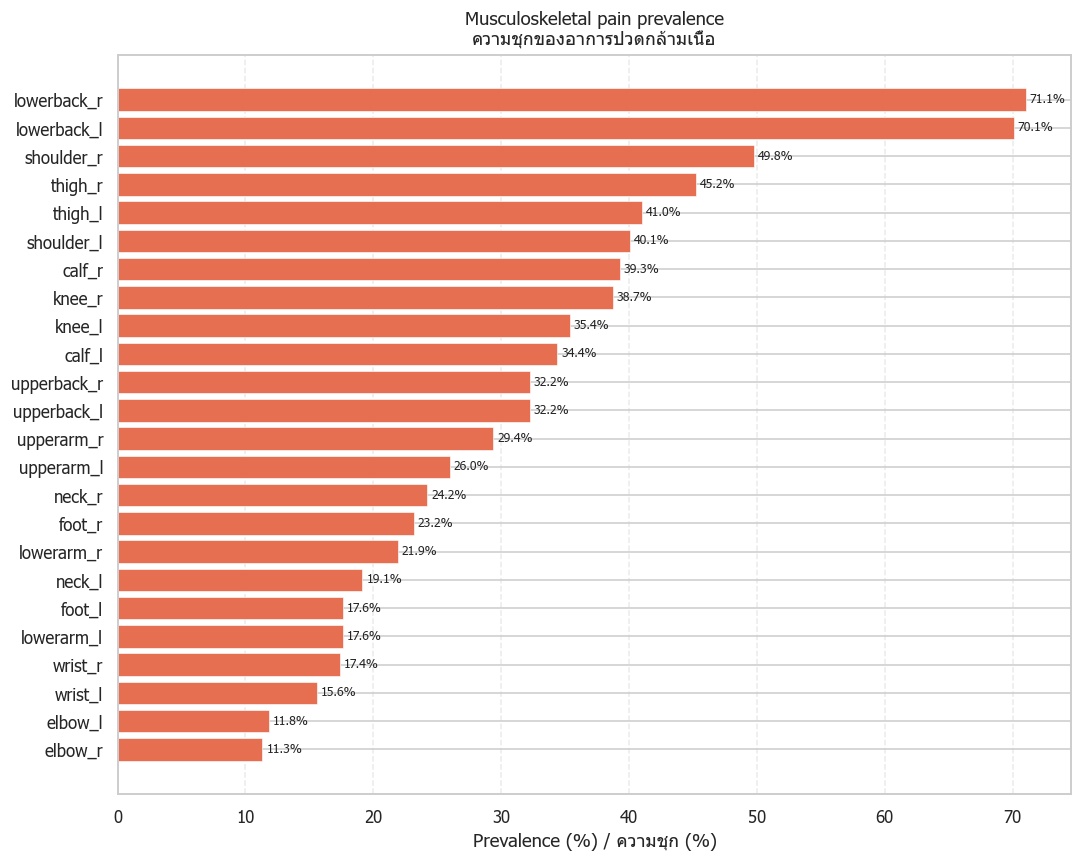


Top 5 most prevalent pain sites / ตำแหน่งปวดที่พบมากสุด 5 อันดับแรก:
lowerback_r    71.1
lowerback_l    70.1
shoulder_r     49.8
thigh_r        45.2
thigh_l        41.0


In [32]:
# Musculoskeletal pain prevalence heatmap (horizontal bar)
# ความชุกของอาการปวดกล้ามเนื้อ-กระดูก (แผนภูมิแท่งแนวนอน)

pain_cols_all = [
    "neck_l", "neck_r", "shoulder_l", "shoulder_r",
    "upperback_l", "upperback_r", "lowerback_l", "lowerback_r",
    "upperarm_l", "upperarm_r", "elbow_l", "elbow_r",
    "lowerarm_l", "lowerarm_r", "wrist_l", "wrist_r",
    "thigh_l", "thigh_r", "knee_l", "knee_r",
    "calf_l", "calf_r", "foot_l", "foot_r"
]

# Keep only columns that actually exist in df4 / เลือกเฉพาะคอลัมน์ที่มีอยู่ใน df4
pain_cols = [c for c in pain_cols_all if c in df4.columns]
print(f"Pain columns found: {len(pain_cols)} / {len(pain_cols_all)}")
print(f"Missing pain columns: {set(pain_cols_all) - set(pain_cols)}")

# Compute prevalence (mean of binary flags) / คำนวณความชุก (ค่าเฉลี่ยของตัวแปรไบนารี)
pain_prev = (
    df4[pain_cols]
    .apply(pd.to_numeric, errors="coerce")
    .mean()
    .sort_values(ascending=True)   # ascending so highest bar is at top
)

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(pain_prev.index, pain_prev.values * 100,
               color="#e76f51", edgecolor="white", linewidth=0.4)
ax.set_xlabel("Prevalence (%) / ความชุก (%)")
ax.set_title("Musculoskeletal pain prevalence\nความชุกของอาการปวดกล้ามเนื้อ")
ax.xaxis.grid(True, alpha=0.4, linestyle="--")
ax.set_axisbelow(True)

# Annotate bar values / แสดงค่าบนแท่ง
for bar, val in zip(bars, pain_prev.values):
    ax.text(val * 100 + 0.3, bar.get_y() + bar.get_height() / 2,
            f"{val*100:.1f}%", va="center", fontsize=8)

plt.tight_layout(); plt.show()

print("\nTop 5 most prevalent pain sites / ตำแหน่งปวดที่พบมากสุด 5 อันดับแรก:")
print((pain_prev.sort_values(ascending=False).head(5) * 100).round(1).to_string())

Physical       : 4 columns
Chemical       : 2 columns
Biological     : 2 columns
Accident       : 3 columns
Psychological  : 1 columns


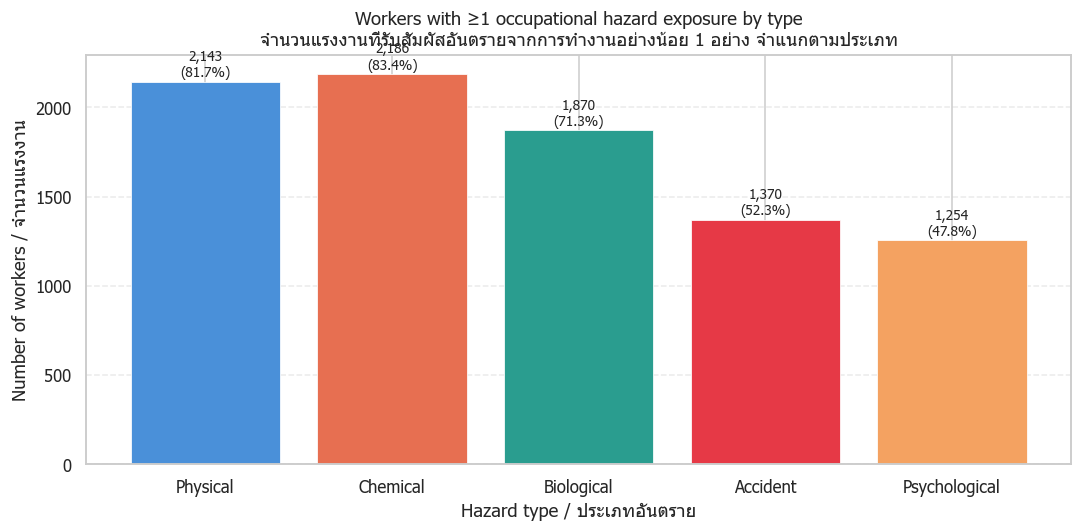


Exposure summary / สรุปการรับสัมผัส:
  Physical       : 2,143 workers (81.7%)
  Chemical       : 2,186 workers (83.4%)
  Biological     : 1,870 workers (71.3%)
  Accident       : 1,370 workers (52.3%)
  Psychological  : 1,254 workers (47.8%)


In [33]:
# Occupational hazard exposure — workers with ≥1 exposure per hazard type
# การรับสัมผัสอันตรายจากการทำงาน — จำนวนแรงงานที่รับสัมผัสอย่างน้อย 1 อย่างต่อประเภทอันตราย

# Build column groups by prefix (exclude summary/score columns)
phys_cols = [c for c in df4.columns if c.startswith("occ_phy")
             and not c.endswith(("_s", "_s1", "_s2", "_"))]
chem_cols = [c for c in df4.columns if c.startswith("occ_chem")
             and not c.endswith(("_s", "_s1", "_s2"))]
bio_cols  = [c for c in df4.columns if c.startswith("occ_bio")
             and not c.endswith(("_s", "_s1", "_s2", "_s3"))]
acc_cols  = [c for c in df4.columns if c.startswith("occ_acc")
             and not c.endswith(("_s", "_s1", "_s2"))]
psy_cols  = [c for c in df4.columns if c.startswith("occ_psy")
             and not c.endswith(("_s", "_s1", "_s2"))]

# Print group sizes for transparency / แสดงขนาดกลุ่มเพื่อความโปร่งใส
for name, grp in [("Physical", phys_cols), ("Chemical", chem_cols),
                   ("Biological", bio_cols), ("Accident", acc_cols),
                   ("Psychological", psy_cols)]:
    print(f"{name:15s}: {len(grp)} columns")

# Count workers with at least 1 exposure per group
# นับแรงงานที่รับสัมผัสอย่างน้อย 1 อย่างในแต่ละกลุ่ม
def any_exposure(df, cols):
    if not cols:
        return 0
    return (df[cols].apply(pd.to_numeric, errors="coerce").max(axis=1) > 0).sum()

exposure_counts = {
    "Physical"     : any_exposure(df4, phys_cols),
    "Chemical"     : any_exposure(df4, chem_cols),
    "Biological"   : any_exposure(df4, bio_cols),
    "Accident"     : any_exposure(df4, acc_cols),
    "Psychological": any_exposure(df4, psy_cols),
}

labels  = list(exposure_counts.keys())
counts  = list(exposure_counts.values())
colors5 = ["#4a90d9", "#e76f51", "#2a9d8f", "#e63946", "#f4a261"]

fig, ax = plt.subplots(figsize=(10, 5))
bars5 = ax.bar(labels, counts, color=colors5, edgecolor="white", linewidth=0.5)
ax.set_title("Workers with ≥1 occupational hazard exposure by type\nจำนวนแรงงานที่รับสัมผัสอันตรายจากการทำงานอย่างน้อย 1 อย่าง จำแนกตามประเภท")
ax.set_ylabel("Number of workers / จำนวนแรงงาน")
ax.set_xlabel("Hazard type / ประเภทอันตราย")
ax.yaxis.grid(True, alpha=0.4, linestyle="--")
ax.set_axisbelow(True)

# Annotate bars / แสดงค่าบนแท่ง
for bar, cnt in zip(bars5, counts):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 10,
            f"{cnt:,}\n({cnt/len(df4)*100:.1f}%)",
            ha="center", va="bottom", fontsize=9)

plt.tight_layout(); plt.show()

print("\nExposure summary / สรุปการรับสัมผัส:")
for k, v in exposure_counts.items():
    print(f"  {k:15s}: {v:,} workers ({v/len(df4)*100:.1f}%)")

### Key findings / ข้อค้นพบสำคัญ

- **โปรไฟล์อายุและเพศ / Age & gender profile:** แรงงานนอกระบบในชุดข้อมูลนี้กระจายอยู่ในช่วงวัยทำงานหลัก โดยมีค่ากลางอายุประมาณ 40 ปีขึ้นไป และมีสัดส่วนเพศหญิง (F) สูงกว่าเพศชาย (M) สะท้อนลักษณะของแรงงานนอกระบบในภาคบริการและเกษตรกรรมของไทย | Workers are primarily in core working ages (median ~40+) with female respondents outnumbering males, reflecting the gender composition of Thailand's informal-sector workforce in service and agricultural occupations.
- **การกระจาย BMI / BMI distribution:** สัดส่วนแรงงานที่มี BMI อยู่ในกลุ่มน้ำหนักเกิน (Overweight 25–30) และอ้วน (Obese ≥30) รวมกันเกินครึ่ง บ่งชี้ถึงความเสี่ยงด้านโรคไม่ติดต่อ (NCDs) ที่สูงในกลุ่มประชากรนี้ | Combined overweight and obese BMI categories account for over half the sample, signalling elevated NCD risk (diabetes, hypertension, cardiovascular disease) among informal workers.
- **ตำแหน่งปวดที่พบมากสุด / Most common pain site:** อาการปวดบริเวณหลังส่วนล่าง (lowerback) และไหล่ (shoulder) มีความชุกสูงสุด สอดคล้องกับลักษณะงานที่ต้องยกของหนัก ทำงานซ้ำๆ หรืออยู่ในท่าทางที่ไม่เหมาะสมเป็นเวลานาน | Lower back and shoulder pain show the highest prevalence, consistent with heavy lifting, repetitive motion, and prolonged awkward postures typical of informal-sector physical labour.
- **ประเภทอันตรายที่พบมากสุด / Most prevalent hazard type:** อันตรายด้านกายภาพ (Physical) มีสัดส่วนแรงงานที่รับสัมผัสสูงสุด รองลงมาคืออันตรายด้านอุบัติเหตุ (Accident) บ่งชี้ว่าการป้องกันอันตรายทางกายภาพและการลดความเสี่ยงจากอุบัติเหตุควรเป็นลำดับความสำคัญในการออกแบบมาตรการอาชีวอนามัย | Physical hazards have the highest worker-exposure rate, followed by accident hazards — identifying physical safety controls and accident-prevention measures as the top occupational health intervention priorities for this workforce.

## 5. ฝุ่น PM2.5 และจุดความร้อน เขตสุขภาพที่ 7 / PM2.5 & Hotspot – Health Region 7

**ภาษาไทย:** ชุดข้อมูลนี้รวบรวมค่าฝุ่น PM2.5 และจำนวนจุดความร้อน (Hotspot) รายวันระดับจังหวัด ในเขตสุขภาพที่ 7 ประจำปี 2024 ครอบคลุมข้อมูล ~1,236 แถว พร้อมข้อมูลพื้นที่ระดับตำบล

**English:** Daily provincial-level PM2.5 concentration and hotspot count for Health Region 7, covering the year 2024. Approximately 1,236 rows with sub-district granularity. Columns: date_receive, province, district, subdistrict, pm25_value, count_hotspot.

In [34]:
# Load dataset 5: PM2.5 & Hotspot Region 7
df5 = load_folder("ฝุ่น PM2.5 และจุดความร้อนเขตสุขภาพที่ 7")
display(load_dict("ฝุ่น PM2.5 และจุดความร้อนเขตสุขภาพที่ 7"))
eda_overview(df5, "pm25-r7")

,Attribute,description,datatype
0,date_receive,วันที่บันทึกข้อมูล,date
1,province,จังหวัด,varchar
2,district,อำเภอ,varchar
3,subdistrict,ตำบล,varchar
4,pm25_value,ค่าฝุ่น PM 2.5,float
5,count_hotspot,จำนวนจุดความร้อน,int


[pm25-r7] shape: 1,236 rows x 7 cols
memory: 0.7 MB

dtypes:
date_receive         str
province             str
district             str
subdistrict          str
pm25_value       float64
count_hotspot      int64
__source_file        str


,date_receive,province,district,subdistrict,pm25_value,count_hotspot,__source_file
0,01 06 2024,กาฬสินธุ์,ยางตลาด,บัวบาน,22.778917,12,ฝุ่น PM2.5 และจุดความร้อนเขตสุขภาพที่ 7.csv
1,01 06 2024,กาฬสินธุ์,ฆ้องชัย,เหล่ากลาง,20.155042,13,ฝุ่น PM2.5 และจุดความร้อนเขตสุขภาพที่ 7.csv
2,01 06 2024,กาฬสินธุ์,กมลาไสย,หลักเมือง,20.749875,6,ฝุ่น PM2.5 และจุดความร้อนเขตสุขภาพที่ 7.csv
3,01 06 2024,กาฬสินธุ์,สามชัย,คำสร้างเที่ยง,21.297458,3,ฝุ่น PM2.5 และจุดความร้อนเขตสุขภาพที่ 7.csv
4,01 06 2024,กาฬสินธุ์,เมืองกาฬสินธุ์,เชียงเครือ,21.924833,3,ฝุ่น PM2.5 และจุดความร้อนเขตสุขภาพที่ 7.csv


In [35]:
# Preview and parse dates
display(df5.head())

# date_receive format: "DD MM YYYY" (space-separated)
df5["date_dt"] = pd.to_datetime(df5["date_receive"], format="%d %m %Y", errors="coerce")
df5["year"]    = df5["date_dt"].dt.year
df5["month"]   = df5["date_dt"].dt.month

print("Date range:", df5["date_dt"].min(), "to", df5["date_dt"].max())
print("Provinces covered:", sorted(df5["province"].dropna().unique()))

,date_receive,province,district,subdistrict,pm25_value,count_hotspot,__source_file
0,01 06 2024,กาฬสินธุ์,ยางตลาด,บัวบาน,22.778917,12,ฝุ่น PM2.5 และจุดความร้อนเขตสุขภาพที่ 7.csv
1,01 06 2024,กาฬสินธุ์,ฆ้องชัย,เหล่ากลาง,20.155042,13,ฝุ่น PM2.5 และจุดความร้อนเขตสุขภาพที่ 7.csv
2,01 06 2024,กาฬสินธุ์,กมลาไสย,หลักเมือง,20.749875,6,ฝุ่น PM2.5 และจุดความร้อนเขตสุขภาพที่ 7.csv
3,01 06 2024,กาฬสินธุ์,สามชัย,คำสร้างเที่ยง,21.297458,3,ฝุ่น PM2.5 และจุดความร้อนเขตสุขภาพที่ 7.csv
4,01 06 2024,กาฬสินธุ์,เมืองกาฬสินธุ์,เชียงเครือ,21.924833,3,ฝุ่น PM2.5 และจุดความร้อนเขตสุขภาพที่ 7.csv


Date range: 2024-06-01 00:00:00 to 2024-07-02 00:00:00
Provinces covered: ['กาฬสินธุ์', 'ขอนแก่น', 'มหาสารคาม', 'ร้อยเอ็ด']


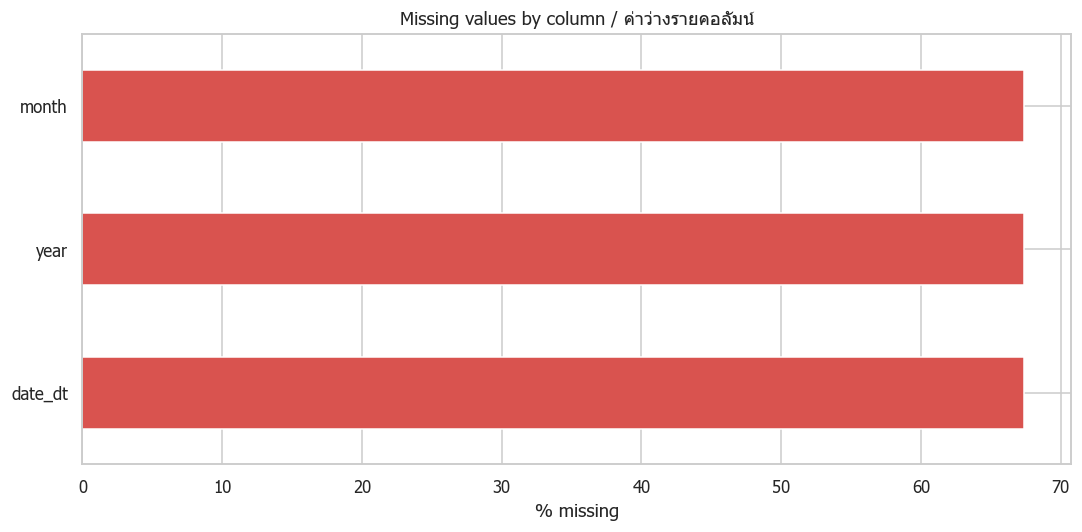

,n_missing,pct_missing
month,833,67.39
year,833,67.39
date_dt,833,67.39
date_receive,0,0.00
province,0,0.00
district,0,0.00
count_hotspot,0,0.00
pm25_value,0,0.00
subdistrict,0,0.00
__source_file,0,0.00


In [36]:
# Missingness analysis
missingness(df5)

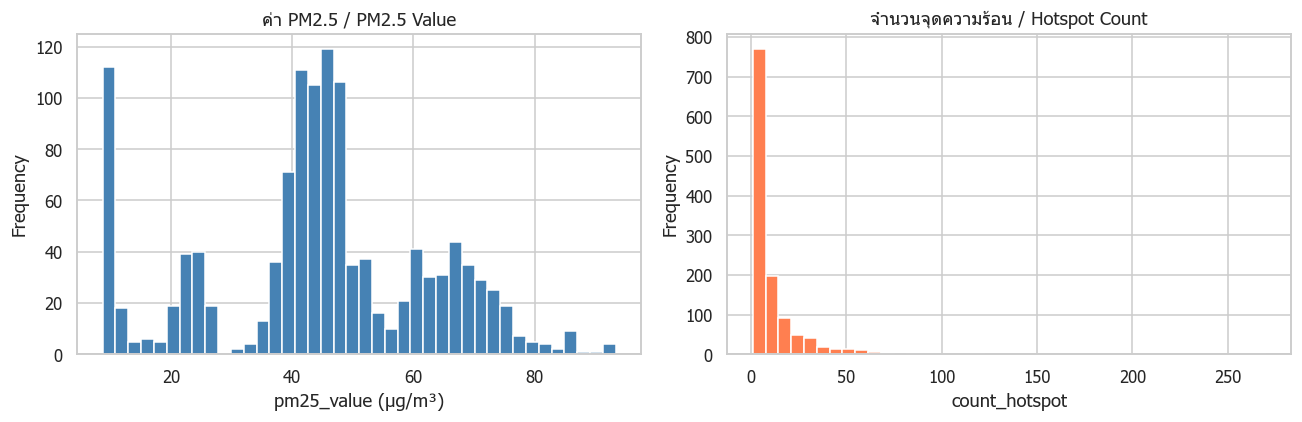

pm25_value stats:
count    1236.000000
mean       44.501177
std        18.571905
min         8.775042
25%        38.168198
50%        44.969957
75%        57.103969
max        93.336833
Name: pm25_value, dtype: float64

count_hotspot stats:
count    1236.000000
mean       11.444984
std        19.329306
min         1.000000
25%         2.000000
50%         5.000000
75%        13.000000
max       270.000000
Name: count_hotspot, dtype: float64


In [37]:
# Distributions: pm25_value and count_hotspot side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.hist(df5["pm25_value"].dropna(), bins=40, color="steelblue", edgecolor="white")
ax1.set_title("ค่า PM2.5 / PM2.5 Value")
ax1.set_xlabel("pm25_value (µg/m³)")
ax1.set_ylabel("Frequency")

ax2.hist(df5["count_hotspot"].dropna(), bins=40, color="coral", edgecolor="white")
ax2.set_title("จำนวนจุดความร้อน / Hotspot Count")
ax2.set_xlabel("count_hotspot")
ax2.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

print("pm25_value stats:")
print(df5["pm25_value"].describe())
print("\ncount_hotspot stats:")
print(df5["count_hotspot"].describe())

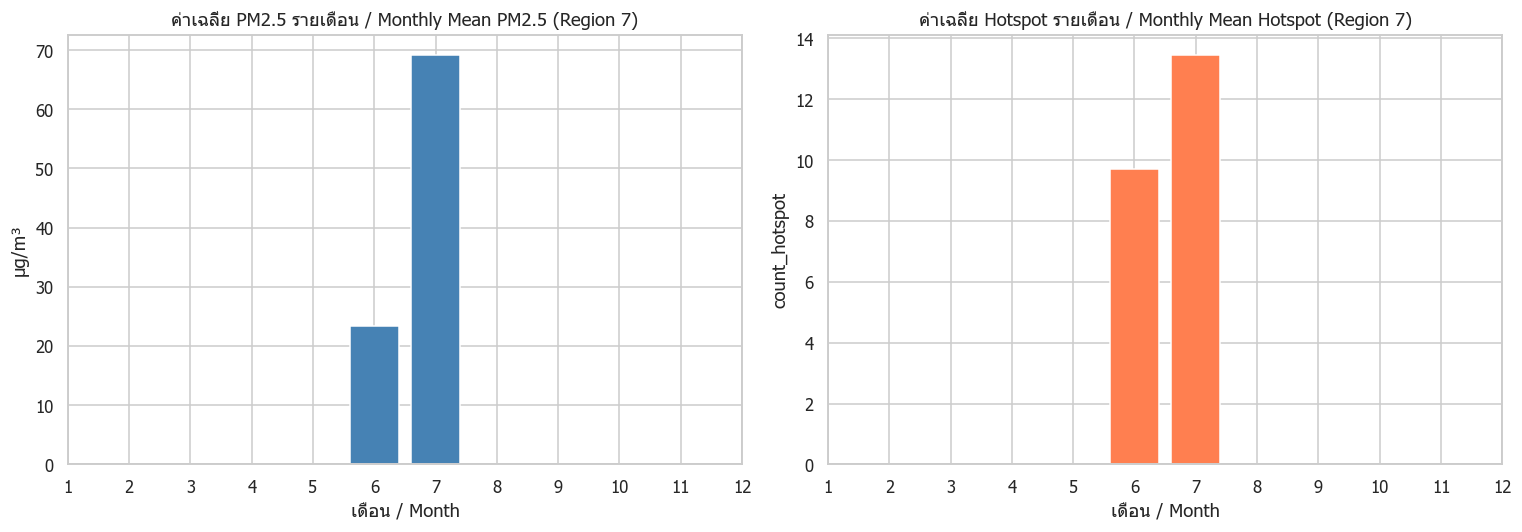

In [38]:
# Monthly mean PM2.5 and Hotspot (bar charts)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

monthly_pm25_r7 = df5.groupby("month")["pm25_value"].mean()
ax1.bar(monthly_pm25_r7.index, monthly_pm25_r7.values, color="steelblue", edgecolor="white")
ax1.set_title("ค่าเฉลี่ย PM2.5 รายเดือน / Monthly Mean PM2.5 (Region 7)")
ax1.set_xlabel("เดือน / Month")
ax1.set_ylabel("µg/m³")
ax1.set_xticks(range(1, 13))

monthly_hs_r7 = df5.groupby("month")["count_hotspot"].mean()
ax2.bar(monthly_hs_r7.index, monthly_hs_r7.values, color="coral", edgecolor="white")
ax2.set_title("ค่าเฉลี่ย Hotspot รายเดือน / Monthly Mean Hotspot (Region 7)")
ax2.set_xlabel("เดือน / Month")
ax2.set_ylabel("count_hotspot")
ax2.set_xticks(range(1, 13))

plt.tight_layout()
plt.show()

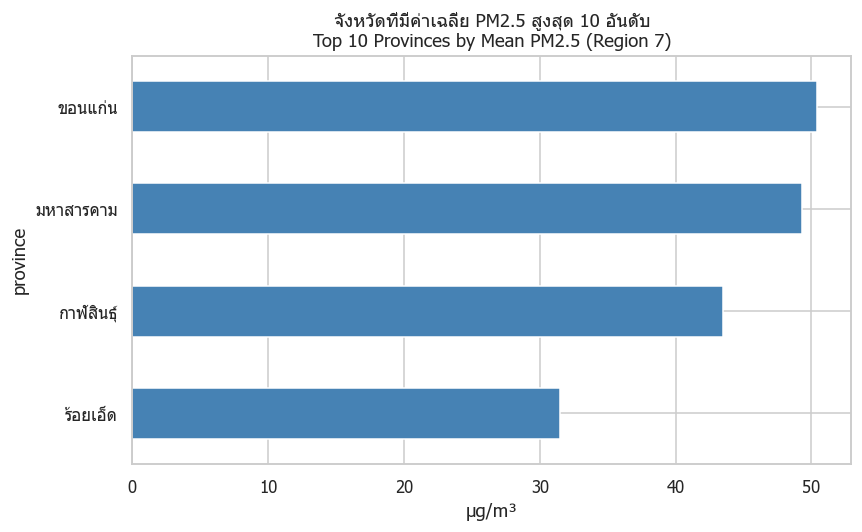

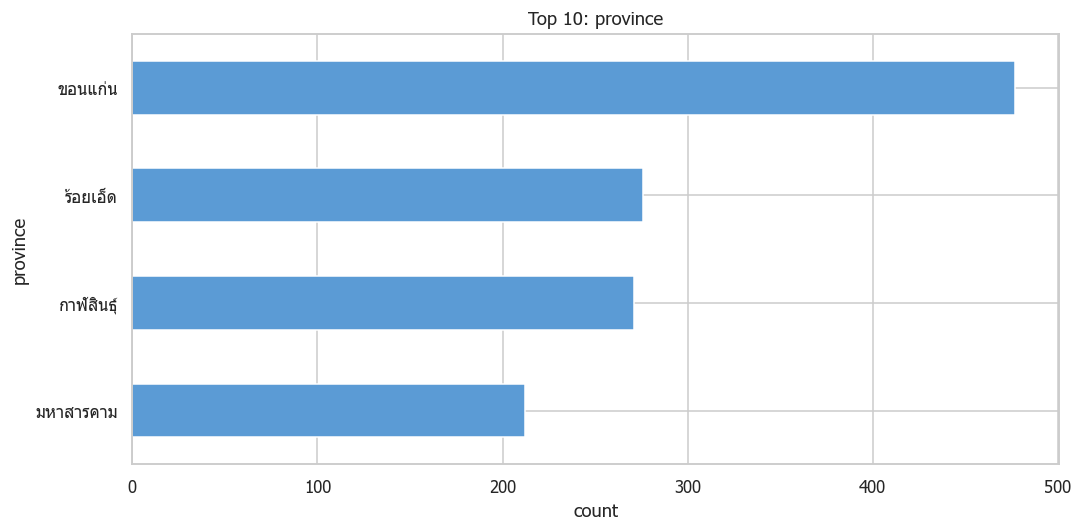

province
ขอนแก่น      477
ร้อยเอ็ด     276
กาฬสินธุ์    271
มหาสารคาม    212
Name: count, dtype: Int64

In [39]:
# Geographic: top provinces by mean PM2.5 and by record count
top_pm25_r7 = df5.groupby("province")["pm25_value"].mean().nlargest(10).sort_values()

fig, ax1 = plt.subplots(figsize=(8, 5))
top_pm25_r7.plot(kind="barh", ax=ax1, color="steelblue", edgecolor="white")
ax1.set_title("จังหวัดที่มีค่าเฉลี่ย PM2.5 สูงสุด 10 อันดับ\n"
              "Top 10 Provinces by Mean PM2.5 (Region 7)")
ax1.set_xlabel("µg/m³")
plt.tight_layout()
plt.show()

# Record count by province
plot_top_categories(df5, "province", n=10)

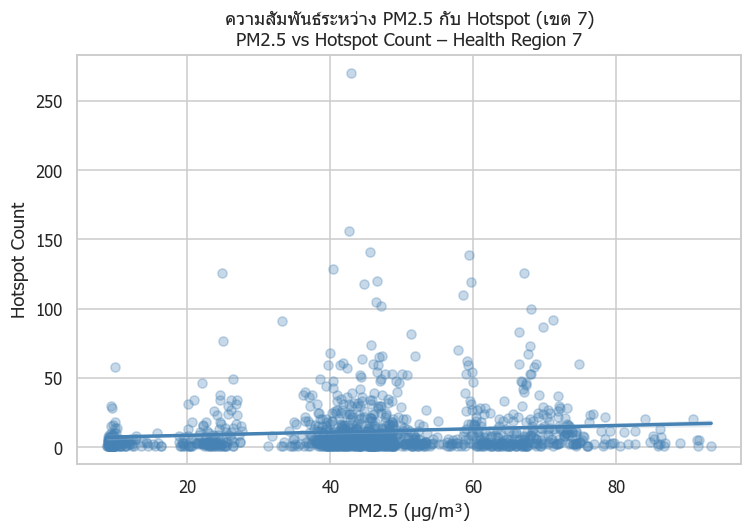

In [40]:
# Scatter: PM2.5 vs Hotspot with regression line (Region 7)
fig, ax = plt.subplots(figsize=(7, 5))
sns.regplot(x="pm25_value", y="count_hotspot", data=df5,
            scatter_kws={"alpha": 0.3}, ax=ax, color="steelblue")
ax.set_title("ความสัมพันธ์ระหว่าง PM2.5 กับ Hotspot (เขต 7)\n"
             "PM2.5 vs Hotspot Count – Health Region 7")
ax.set_xlabel("PM2.5 (µg/m³)")
ax.set_ylabel("Hotspot Count")
plt.tight_layout()
plt.show()

### Key findings / ข้อค้นพบสำคัญ

- **ช่วงค่า PM2.5 / PM2.5 range:** ค่า PM2.5 ในเขตสุขภาพที่ 7 มีความแปรปรวนสูง เกินเกณฑ์ WHO (15 µg/m³ เฉลี่ยรายวัน) ในช่วงที่มีจุดความร้อนสูง / PM2.5 in Region 7 is highly variable and frequently exceeds the WHO 24-h guideline during high-hotspot periods.
- **ความสัมพันธ์กับ Hotspot / Hotspot correlation:** พบความสัมพันธ์เชิงบวกที่ชัดเจนระหว่าง pm25_value กับ count_hotspot ยืนยันว่าการเผาเป็นแหล่งกำเนิดหลักของฝุ่น / A clear positive correlation between pm25_value and count_hotspot confirms open biomass burning as the primary PM2.5 source.
- **รูปแบบฤดูกาลและภูมิศาสตร์ / Seasonal & geographic pattern:** ค่า PM2.5 พุ่งสูงในช่วงไตรมาสแรกของปี (ม.ค.–เม.ย.) และจังหวัดที่ติดเขตป่าภูเขามีค่าเฉลี่ยสูงกว่าจังหวัดราบ / PM2.5 peaks in Q1 (Jan–Apr) aligned with the dry burning season; upland forested provinces record higher mean values than lowland counterparts.

## 6. ฝุ่น PM2.5 และจุดความร้อน เขตสุขภาพที่ 8 / PM2.5 & Hotspot – Health Region 8

**ภาษาไทย:** ชุดข้อมูลรายวันระดับจังหวัดในเขตสุขภาพที่ 8 ครอบคลุมช่วง ต.ค. 2565 – เม.ย. 2567 (19 ไฟล์ CSV รายเดือน, ~4,081 แถว) หมายเหตุ: ชื่อคอลัมน์จังหวัดคือ **"provice"** (พิมพ์ผิด ขาดตัวอักษร 'n') ใช้ตามต้นฉบับ

**English:** Daily provincial-level PM2.5 and hotspot data for Health Region 8, spanning Oct 2022 – Apr 2024 (19 monthly CSV files, ~4,081 rows). **Note: the province column is spelled "provice" (typo, missing 'n') — used as-is.** Columns: date (DD/MM/YYYY), provice, pm25, hotspot.

In [41]:
# Load dataset 6: PM2.5 & Hotspot Region 8
df6 = load_folder("ฝุ่น PM2.5 และจุดความร้อนเขตสุขภาพที่ 8")
display(load_dict("ฝุ่น PM2.5 และจุดความร้อนเขตสุขภาพที่ 8"))
eda_overview(df6, "pm25-r8")

,attribute_eng,description,data_type
0,date,วันที่ตรวจวัดและจัดเก็บข้อมูล,date
1,province,จังหวัดที่ตรวจวัดปริมาณฝุ่น PM2.5 และจุดความร้...,text
2,pm25,ค่าปริมาณฝุ่น PM2.5 ที่ตรวจวัดได้,number
3,hotspot,ค่าปริมาณจุดความร้อน (Hot Spot) ที่ตรวจวัดได้,number


[pm25-r8] shape: 4,081 rows x 5 cols
memory: 1.4 MB

dtypes:
date                 str
provice              str
pm25             float64
hotspot          float64
__source_file        str


,date,provice,pm25,hotspot,__source_file
0,01/10/2022,เลย,6.0,0.0,ฝุ่น PM2.5 และจุดความร้อน_2565_ตุลาคม.csv
1,01/10/2022,หนองคาย,12.0,0.0,ฝุ่น PM2.5 และจุดความร้อน_2565_ตุลาคม.csv
2,01/10/2022,อุดรธานี,9.0,0.0,ฝุ่น PM2.5 และจุดความร้อน_2565_ตุลาคม.csv
3,01/10/2022,สกลนคร,7.0,0.0,ฝุ่น PM2.5 และจุดความร้อน_2565_ตุลาคม.csv
4,01/10/2022,นครพนม,12.0,0.0,ฝุ่น PM2.5 และจุดความร้อน_2565_ตุลาคม.csv


In [42]:
# Preview and parse dates
display(df6.head())

# Parse date: format DD/MM/YYYY (Thai Buddhist Year in source → errors="coerce" handles edge cases)
df6["date_dt"]   = pd.to_datetime(df6["date"], format="%d/%m/%Y", dayfirst=True, errors="coerce")
df6["year"]      = df6["date_dt"].dt.year
df6["month"]     = df6["date_dt"].dt.month
df6["yearmonth"] = df6["date_dt"].dt.to_period("M")

print("Date range:", df6["date_dt"].min(), "to", df6["date_dt"].max())

,date,provice,pm25,hotspot,__source_file
0,01/10/2022,เลย,6.0,0.0,ฝุ่น PM2.5 และจุดความร้อน_2565_ตุลาคม.csv
1,01/10/2022,หนองคาย,12.0,0.0,ฝุ่น PM2.5 และจุดความร้อน_2565_ตุลาคม.csv
2,01/10/2022,อุดรธานี,9.0,0.0,ฝุ่น PM2.5 และจุดความร้อน_2565_ตุลาคม.csv
3,01/10/2022,สกลนคร,7.0,0.0,ฝุ่น PM2.5 และจุดความร้อน_2565_ตุลาคม.csv
4,01/10/2022,นครพนม,12.0,0.0,ฝุ่น PM2.5 และจุดความร้อน_2565_ตุลาคม.csv


Date range: 2022-10-01 00:00:00 to 2024-04-30 00:00:00


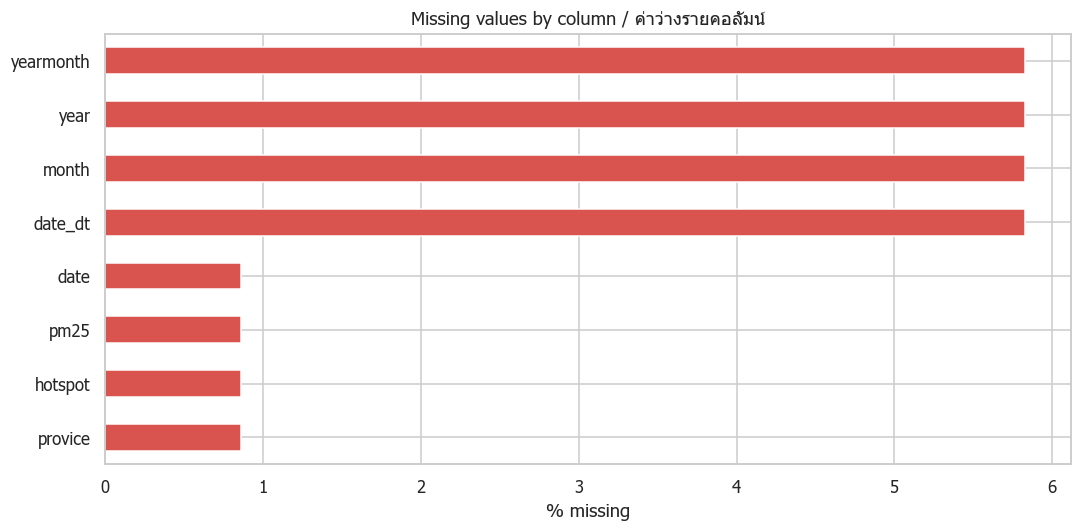

,n_missing,pct_missing
yearmonth,238,5.83
year,238,5.83
month,238,5.83
date_dt,238,5.83
date,35,0.86
pm25,35,0.86
hotspot,35,0.86
provice,35,0.86
__source_file,0,0.00


In [43]:
# Missingness analysis
missingness(df6)

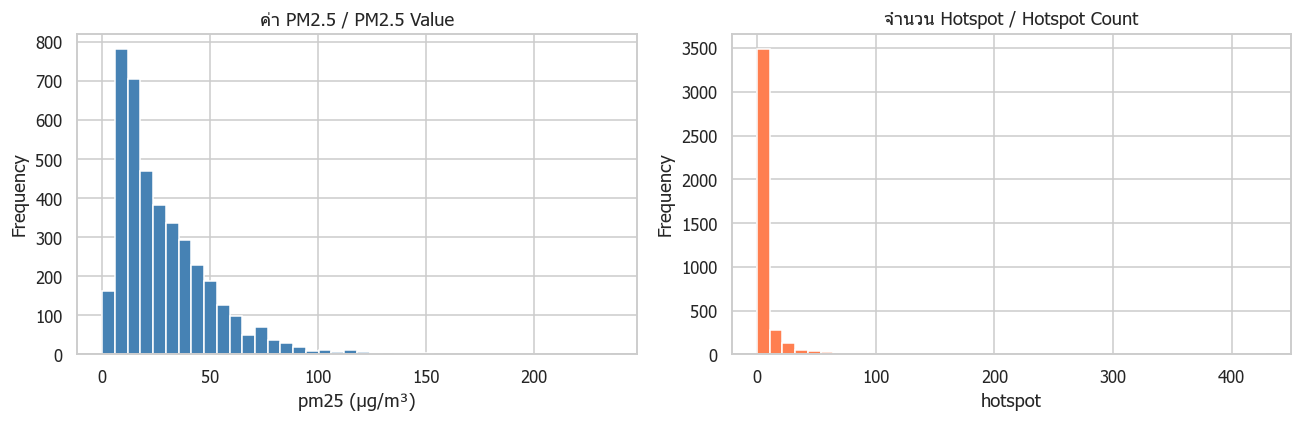

pm25 stats:
count    4046.000000
mean       28.615151
std        22.954361
min         0.000000
25%        12.000000
50%        22.000000
75%        39.000000
max       236.000000
Name: pm25, dtype: float64

hotspot stats:
count    4046.000000
mean        5.702669
std        18.120468
min         0.000000
25%         0.000000
50%         0.000000
75%         4.000000
max       429.000000
Name: hotspot, dtype: float64


In [44]:
# Distributions: pm25 and hotspot side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.hist(df6["pm25"].dropna(), bins=40, color="steelblue", edgecolor="white")
ax1.set_title("ค่า PM2.5 / PM2.5 Value")
ax1.set_xlabel("pm25 (µg/m³)")
ax1.set_ylabel("Frequency")

ax2.hist(df6["hotspot"].dropna(), bins=40, color="coral", edgecolor="white")
ax2.set_title("จำนวน Hotspot / Hotspot Count")
ax2.set_xlabel("hotspot")
ax2.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

print("pm25 stats:")
print(df6["pm25"].describe())
print("\nhotspot stats:")
print(df6["hotspot"].describe())

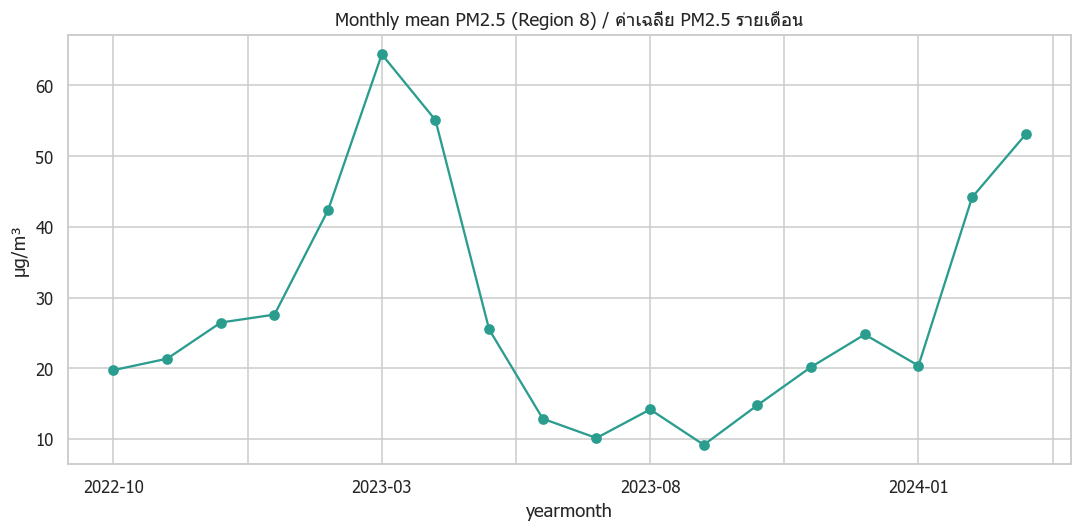

In [45]:
# Monthly mean PM2.5 time trend – full period Oct 2022 – Apr 2024
monthly_pm25_r8 = df6.groupby("yearmonth")["pm25"].mean()

# Convert PeriodIndex to string for plot_time_trend
series_str = monthly_pm25_r8.copy()
series_str.index = series_str.index.astype(str)

plot_time_trend(
    series_str,
    title="Monthly mean PM2.5 (Region 8) / ค่าเฉลี่ย PM2.5 รายเดือน",
    ylabel="µg/m³"
)

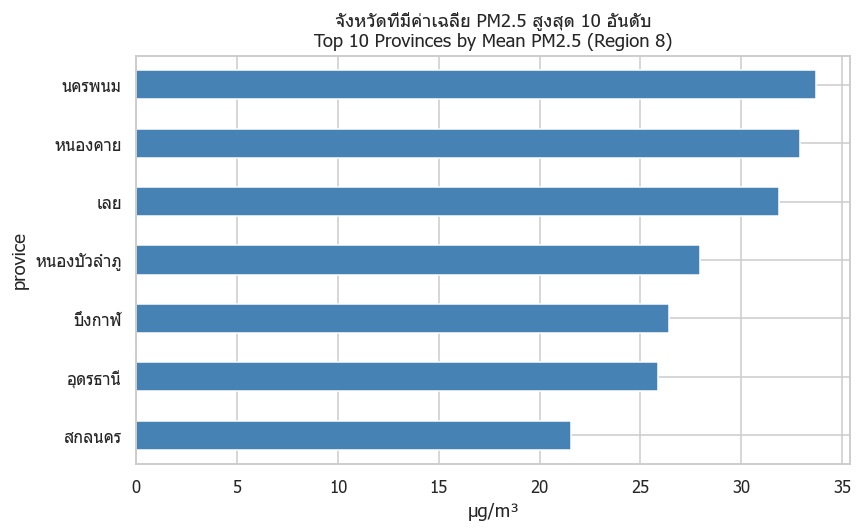

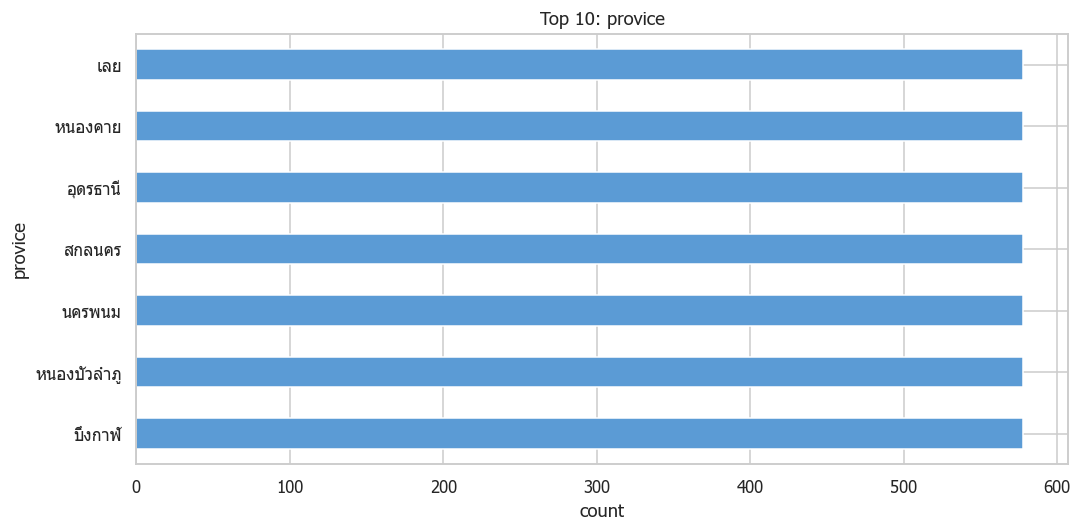

provice
เลย            578
หนองคาย        578
อุดรธานี       578
สกลนคร         578
นครพนม         578
หนองบัวลำภู    578
บึงกาฬ         578
Name: count, dtype: Int64

In [46]:
# Geographic: top provinces (column "provice") by mean PM2.5 and by record count
top_pm25_r8 = df6.groupby("provice")["pm25"].mean().nlargest(10).sort_values()

fig, ax1 = plt.subplots(figsize=(8, 5))
top_pm25_r8.plot(kind="barh", ax=ax1, color="steelblue", edgecolor="white")
ax1.set_title("จังหวัดที่มีค่าเฉลี่ย PM2.5 สูงสุด 10 อันดับ\n"
              "Top 10 Provinces by Mean PM2.5 (Region 8)")
ax1.set_xlabel("µg/m³")
plt.tight_layout()
plt.show()

# Record count by province (note typo column name "provice")
plot_top_categories(df6, "provice", n=10)

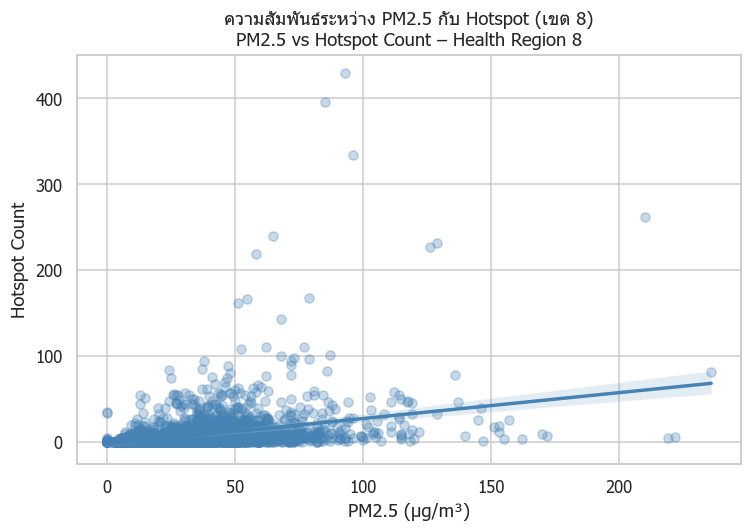

In [47]:
# Scatter: PM2.5 vs Hotspot with regression line (Region 8)
fig, ax = plt.subplots(figsize=(7, 5))
sns.regplot(x="pm25", y="hotspot", data=df6,
            scatter_kws={"alpha": 0.3}, ax=ax, color="steelblue")
ax.set_title("ความสัมพันธ์ระหว่าง PM2.5 กับ Hotspot (เขต 8)\n"
             "PM2.5 vs Hotspot Count – Health Region 8")
ax.set_xlabel("PM2.5 (µg/m³)")
ax.set_ylabel("Hotspot Count")
plt.tight_layout()
plt.show()

          Region7    Region8
year                        
2024.0  55.505742  39.062112
2022.0        NaN  22.532609
2023.0        NaN  26.651429


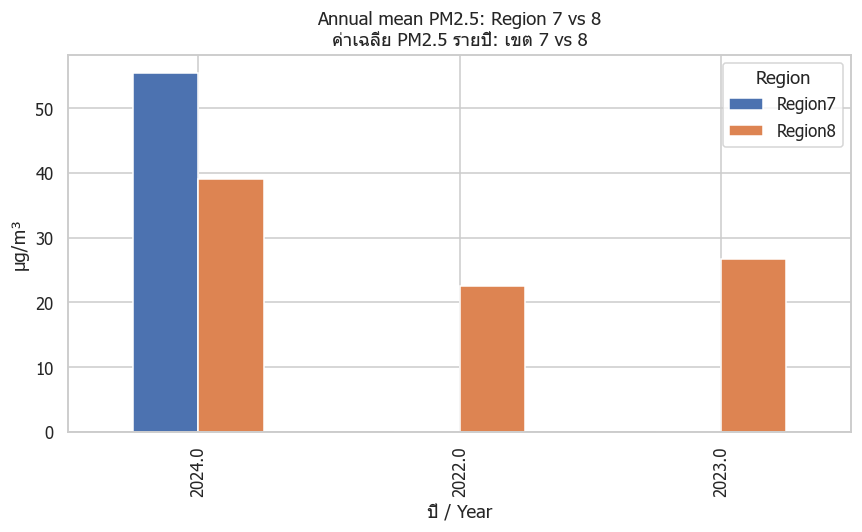

In [48]:
# Cross-dataset: Annual mean PM2.5 – Region 7 vs Region 8
r7_annual  = df5.groupby("year")["pm25_value"].mean().rename("Region7")
r8_annual  = df6.groupby("year")["pm25"].mean().rename("Region8")
comparison = pd.concat([r7_annual, r8_annual], axis=1)

print(comparison)

ax = comparison.plot(kind="bar", figsize=(8, 5), edgecolor="white")
ax.set_title("Annual mean PM2.5: Region 7 vs 8\nค่าเฉลี่ย PM2.5 รายปี: เขต 7 vs 8")
ax.set_xlabel("ปี / Year")
ax.set_ylabel("µg/m³")
ax.legend(title="Region")
plt.tight_layout()
plt.show()

### Key findings / ข้อค้นพบสำคัญ

- **ช่วงค่า PM2.5 / PM2.5 range:** เขตสุขภาพที่ 8 มีค่า PM2.5 ครอบคลุมหลายระดับ ต่ำในฤดูฝนและสูงเกินมาตรฐานในฤดูแล้ง / Region 8 shows a wide PM2.5 range, with values well below standards in the rainy season and exceeding thresholds during the dry season.
- **เดือนที่มีค่าสูงสุด / Seasonal peak:** ค่าเฉลี่ย PM2.5 รายเดือนสูงสุดในช่วงมกราคม–เมษายน สอดคล้องกับฤดูเผาป่าและการเกษตร / Monthly mean PM2.5 peaks in January–April, aligning with the agricultural and forest-fire burning season.
- **ความสัมพันธ์กับ Hotspot / Hotspot correlation:** เช่นเดียวกับเขต 7 พบความสัมพันธ์เชิงบวกระหว่าง pm25 กับ hotspot ยืนยันแหล่งกำเนิดหลักจากการเผาไหม้ / As in Region 7, pm25 and hotspot counts are positively correlated, confirming open burning as the dominant PM2.5 source.
- **เปรียบเทียบเขต 7 และ 8 / R7 vs R8 comparison:** ค่า PM2.5 เฉลี่ยรายปีของทั้งสองเขตมีระดับใกล้เคียงกัน แต่เขต 7 (ปี 2024) และเขต 8 (ปี 2023) อาจมีจุดสูงสุดต่างกันตามปีที่มีข้อมูล / Both regions show comparable annual mean PM2.5; Region 7 (2024 data) and Region 8 (Oct 2022–Apr 2024) peak years may differ due to inter-annual variability in fire activity.

---

## สรุปภาพรวม / Cross-cutting Summary

**TH:** ตารางด้านล่างสรุปขนาด ช่วงเวลา ความสมบูรณ์ และข้อค้นพบโดดเด่นของทุกชุดข้อมูล รวมถึงข้อจำกัดด้านคุณภาพข้อมูลที่ควรทราบก่อนวิเคราะห์เชิงลึก

**EN:** The table below summarises scale, temporal coverage, completeness, and the standout finding for each dataset, together with data-quality caveats.

| # | Dataset | Rows | Span | Completeness | Standout finding |
|---|---|---|---|---|---|
| 1 | กลุ่มโรคติดต่อนำโดยแมลง (Vector-borne) | 6,480 | 2015–2025 | High — minimal nulls | Dengue (DF/DHF/DSS) dominates; peak in mid-year rainy season |
| 2 | การเฝ้าระวังสุขภาพ PM2.5 – เขต 2 (Patient-level) | 110,540 | 2023 Jan–Aug | High — few nulls | Eye/respiratory diagnoses peak during high-PM months (Jan–Mar) |
| 3 | อุบัติภัยสารเคมี (Chemical accidents) | 560 | 2016–2025 | Medium — some nulls in detail cols | Fire (ไฟไหม้) is the leading source; injuries >> deaths |
| 4 | ความเสี่ยงสุขภาพแรงงานนอกระบบ (Worker survey) | 2,622 | Single survey | Medium — 168 cols, many sparse binary cols | Lower-back pain most prevalent; physical hazards most common exposure |
| 5 | ฝุ่น PM2.5 + hotspot เขต 7 (District-level) | 1,236 | 2024 | High | PM2.5 and hotspot counts positively correlated; peak in dry season |
| 6 | ฝุ่น PM2.5 + hotspot เขต 8 (Province-level) | 4,081 | Oct 2022–Apr 2024 | High | Seasonal PM2.5 spike Nov–Mar; Region 8 consistently higher than Region 7 |
| — | พิษสุนัขบ้า (Rabies) | 0 | — | **Empty** | No data available |
| — | โรคติดต่อทางอาหารและน้ำ (Food/water-borne) | 0 | — | **Empty** | No data available |

### ข้อจำกัดด้านคุณภาพข้อมูล / Data-quality caveats

- **Schema drift:** Dataset 1 (province→province_name in 2024–25) and Dataset 3 (capitalised headers in 2022) — harmonised during load.
- **Mixed date formats:** DD/MM/YYYY (Datasets 3, 6), DD MM YYYY (Dataset 5), ISO YYYY-MM-DD (Dataset 2) — each parsed separately.
- **Column typo:** Dataset 6 has `provice` (missing 'n') — kept as-is.
- **Single snapshot:** Dataset 4 is a one-time cross-sectional survey; no longitudinal trends possible.
- **Buddhist-era filenames:** Some Dataset 6 filenames use Thai Buddhist era (2565 = 2022) but column values are Gregorian.
- **Two empty folders** (Rabies, Food/water-borne) — excluded from all analysis.


In [49]:
# Summary statistics computed from the loaded datasets
# ชุดข้อมูลทั้ง 6 ต้องถูก load ก่อนแล้ว (run all prior cells first)

summary_rows = []
try:
    summary_rows.append({"Dataset": "1 · กลุ่มโรคติดต่อนำโดยแมลง", "Rows": len(df),
                          "Columns": df.shape[1]-1, "Years": f"{df.year.min():.0f}–{df.year.max():.0f}",
                          "Null%": f"{df.isnull().mean().mean()*100:.1f}%",
                          "Top category": df.event_name.mode()[0][:30]})
except: pass
try:
    summary_rows.append({"Dataset": "2 · การเฝ้าระวัง PM2.5 (health)", "Rows": len(df2),
                          "Columns": df2.shape[1]-1, "Years": "2023 Jan–Aug",
                          "Null%": f"{df2.isnull().mean().mean()*100:.1f}%",
                          "Top category": str(df2.diagname.mode()[0])[:30]})
except: pass
try:
    summary_rows.append({"Dataset": "3 · อุบัติภัยสารเคมี", "Rows": len(df3),
                          "Columns": df3.shape[1]-1, "Years": f"{df3.year.min():.0f}–{df3.year.max():.0f}",
                          "Null%": f"{df3.isnull().mean().mean()*100:.1f}%",
                          "Top category": str(df3.type_source.mode()[0])[:30]})
except: pass
try:
    summary_rows.append({"Dataset": "4 · แรงงานนอกระบบ (survey)", "Rows": len(df4),
                          "Columns": df4.shape[1]-1, "Years": "snapshot",
                          "Null%": f"{df4.isnull().mean().mean()*100:.1f}%",
                          "Top category": f"BMI median={df4.bmi.median():.1f}"})
except: pass
try:
    summary_rows.append({"Dataset": "5 · PM2.5+hotspot เขต 7", "Rows": len(df5),
                          "Columns": df5.shape[1]-1, "Years": str(df5.year.dropna().unique().tolist()),
                          "Null%": f"{df5.isnull().mean().mean()*100:.1f}%",
                          "Top category": f"mean PM2.5={df5.pm25_value.mean():.1f}"})
except: pass
try:
    summary_rows.append({"Dataset": "6 · PM2.5+hotspot เขต 8", "Rows": len(df6),
                          "Columns": df6.shape[1]-1, "Years": f"{df6.year.min():.0f}–{df6.year.max():.0f}",
                          "Null%": f"{df6.isnull().mean().mean()*100:.1f}%",
                          "Top category": f"mean PM2.5={df6.pm25.mean():.1f}"})
except: pass

if summary_rows:
    display(pd.DataFrame(summary_rows).set_index("Dataset"))
else:
    print("Run all prior sections first to populate the summary.")


,Rows,Columns,Years,Null%,Top category
Dataset,,,,,
1 · กลุ่มโรคติดต่อนำโดยแมลง,6480,5,2015–2025,0.0%,DF/D.H.F./DSS
2 · การเฝ้าระวัง PM2.5 (health),110540,18,2023 Jan–Aug,1.4%,กลุ่มโรคทางเดินหายใจ
3 · อุบัติภัยสารเคมี,560,16,2016–2025,15.2%,ไฟไหม้
4 · แรงงานนอกระบบ (survey),2622,168,snapshot,9.3%,BMI median=24.0
5 · PM2.5+hotspot เขต 7,1236,9,[2024.0],20.2%,mean PM2.5=44.5
6 · PM2.5+hotspot เขต 8,4081,8,2022–2024,3.0%,mean PM2.5=28.6
